In [3]:
# base libraries
import pandas as pd
import numpy as np 
import pingouin as pg
import os

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.colors as mcolors
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.power import TTestIndPower
from statsmodels.formula.api import ols
import pingouin as pg

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split, GridSearchCV

from IPython.display import clear_output

from sklearn.decomposition import PCA
import sklearn.cluster as sk_cluster
import sklearn.metrics as metrics
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import linkage, dendrogram

import math
from math import sqrt

import scipy.stats
from scipy import stats
from scipy.stats import ttest_ind

from datetime import datetime, timedelta

import researchpy as rp

import shap

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.utils.validation")

In [5]:
# Adjust the path to match your Box sync folder location
box_path = os.path.expanduser(r"C:\Users\HIALAB\Box\Human_AGV_project\ISU_Modeling\Code")

In [7]:
# Specify the directory and filename
save_dir = "./Images/"

In [9]:
model_data = pd.read_csv(os.path.join(box_path, 'Per_Interaction_Data_Merged.csv'))
study_data = pd.read_csv(os.path.join(box_path, 'study_data_processed.csv'))

## Preprocessing

In [14]:
model_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,AGV_Path_Complexity,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First
0,1,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,Straight,103.457506,True,74.580213,100.420508,730.13,1188.92,1532.83,1771.61,N\A
1,1,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,Complex,211.137767,True,47.888087,232.345812,14.56,97.05,108.21,247.34,N\A
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,Complex,211.137767,True,63.130599,120.176130,282.09,482.54,821.32,1067.08,User
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,Complex,211.137767,True,43.571998,263.284416,421.34,544.15,577.55,610.84,User
4,1,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,Complex,147.796437,True,93.720008,91.614207,486.65,852.85,1225.51,1722.14,N\A


In [16]:
study_data.head()

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Yaw,AGV_Roll,AGV_spd,Timestamp,AGVname,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance
0,5051.235,8610.83,-209.725,-21.416662,-92.196247,-0.159610,60.524000,-107.387000,156.022000,4990.711200,...,89.999444,0.002393,0.000238,2024-10-25 15:02:48.900,1,1,High,0.0,0.000000,6812.026513
1,5051.235,8610.83,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,89.999339,-0.000460,0.154715,2024-10-25 15:02:49.000,1,1,High,0.0,84.241150,6811.521389
2,5051.235,8610.83,-209.725,-21.240655,-92.761660,0.339485,60.271857,-108.963714,156.053429,4990.963429,...,89.999565,-0.001784,0.526054,2024-10-25 15:02:49.100,1,1,High,0.0,74.712591,6809.601293
3,5051.235,8610.83,-209.725,-21.004733,-93.120707,0.251285,59.831714,-109.665143,156.194286,4991.403286,...,90.000198,-0.001954,0.893006,2024-10-25 15:02:49.200,1,1,High,0.0,35.834089,6806.150079
4,5051.235,8610.83,-209.725,-20.717933,-91.225685,0.512156,59.295143,-110.065286,156.430571,4991.940286,...,90.001157,-0.001464,1.263035,2024-10-25 15:02:49.300,1,1,High,0.0,66.574460,6801.168018


In [18]:
model_data.columns

Index(['PID', 'DRate', 'date', 'hr', 'min', 's', 'AGVname', 'StartTime',
       'EndTime', 'GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd',
       'task', 'Trust', 'Safe', 'Comfort', 'Expect', 'Age', 'Gender',
       'Ethnicity', 'GamingFrequency', 'VRExperience', 'VRHeadsetExperience',
       'AGVInteraction', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience', 'Trust1', 'Trust2', 'MWL', 'Assessment',
       'Gaze_on_AGV', 'User_Trajectory', 'AGV_Approaching',
       'AGV_User_Combination', 'AGV_Path_Complexity', 'Trust_before',
       'Cross_First_Flag', 'User_Relative_Speed', 'AGV_Relative_Speed',
       'Frechet_Distance_3', 'Frechet_Distance_5', 'Frechet_Distance_7',
       'Frechet_Distance_10', 'Cross_First'],
      dtype='object')

In [20]:
study_data.columns

Index(['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll',
       'U_X', 'U_Y', 'U_Z', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence',
       'Gaze_on_AGV', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd', 'Timestamp', 'AGVname', 'PID', 'DRate',
       'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance'],
      dtype='object')

In [22]:
print(model_data.dtypes)

PID                       int64
DRate                    object
date                     object
hr                        int64
min                       int64
s                         int64
AGVname                   int64
StartTime                object
EndTime                  object
GazeDuration              int64
mean_dist               float64
min_dist                float64
max_dist                float64
std_dist                float64
mean_agv_spd            float64
min_agv_spd             float64
max_agv_spd             float64
std_spd                 float64
task                       bool
Trust                     int64
Safe                      int64
Comfort                   int64
Expect                    int64
Age                     float64
Gender                  float64
Ethnicity               float64
GamingFrequency          object
VRExperience             object
VRHeadsetExperience      object
AGVInteraction           object
PerfectAutomation       float64
TrustPro

In [24]:
print(study_data.dtypes)

User_X                 float64
User_Y                 float64
User_Z                 float64
User_Pitch             float64
User_Yaw               float64
User_Roll              float64
U_X                    float64
U_Y                    float64
U_Z                    float64
GazeOrigin_X           float64
GazeOrigin_Y           float64
GazeOrigin_Z           float64
GazeDirection_X        float64
GazeDirection_Y        float64
GazeDirection_Z        float64
Confidence             float64
Gaze_on_AGV            float64
AGV_X                  float64
AGV_Y                  float64
AGV_Z                  float64
AGV_Pitch              float64
AGV_Yaw                float64
AGV_Roll               float64
AGV_spd                float64
Timestamp               object
AGVname                  int64
PID                      int64
DRate                   object
User_Relative_Speed    float64
AGV_Relative_Speed     float64
AGV_User_distance      float64
dtype: object


### Adding Interaction No

In [27]:
model_data["Interaction No"] = model_data.groupby(['PID', 'DRate']).cumcount() + 1

In [29]:
model_data['PID'] = model_data['PID'].apply(lambda x: str(x).zfill(3))
study_data['PID'] = study_data['PID'].apply(lambda x: str(x).zfill(3))

In [30]:
model_data.iloc[5:10]

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Interaction No
5,001,High,2024-5-3,14,28,53,6,1900-01-01 15:07:56,1900-01-01 15:08:58,1195,...,105.568884,True,60.027827,106.258645,560.04,838.76,1112.20,1473.42,N\A,6
6,001,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,147.796437,True,62.064945,228.573947,379.71,540.52,665.30,941.60,User,7
7,001,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,168.910214,True,59.394993,161.124764,331.78,693.33,1038.91,1483.72,User,8
8,001,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,84.455107,True,59.041137,161.124877,115.79,379.19,541.15,1029.62,AGV,9
9,001,High,2024-5-3,14,28,53,10,1900-01-01 15:12:20,1900-01-01 15:13:08,673,...,190.023991,True,59.998630,205.597358,283.86,567.07,896.84,1312.11,AGV,10


### Cross First Data Analysis

In [34]:
# Filter the data where cross_first is 'AGV' or 'User'
cross_first_data = model_data[model_data['Cross_First'].isin(['AGV', 'User'])]
cross_first_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Interaction No
2,001,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,211.137767,True,63.130599,120.176130,282.09,482.54,821.32,1067.08,User,3
3,001,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,211.137767,True,43.571998,263.284416,421.34,544.15,577.55,610.84,User,4
6,001,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,147.796437,True,62.064945,228.573947,379.71,540.52,665.30,941.60,User,7
7,001,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,168.910214,True,59.394993,161.124764,331.78,693.33,1038.91,1483.72,User,8
8,001,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,84.455107,True,59.041137,161.124877,115.79,379.19,541.15,1029.62,AGV,9


In [36]:
# Drop entries where PID is 35 and overwrite the dataset
cross_first_data = cross_first_data[cross_first_data['PID'] != '035']
cross_first_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Interaction No
2,001,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,211.137767,True,63.130599,120.176130,282.09,482.54,821.32,1067.08,User,3
3,001,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,211.137767,True,43.571998,263.284416,421.34,544.15,577.55,610.84,User,4
6,001,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,147.796437,True,62.064945,228.573947,379.71,540.52,665.30,941.60,User,7
7,001,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,168.910214,True,59.394993,161.124764,331.78,693.33,1038.91,1483.72,User,8
8,001,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,84.455107,True,59.041137,161.124877,115.79,379.19,541.15,1029.62,AGV,9


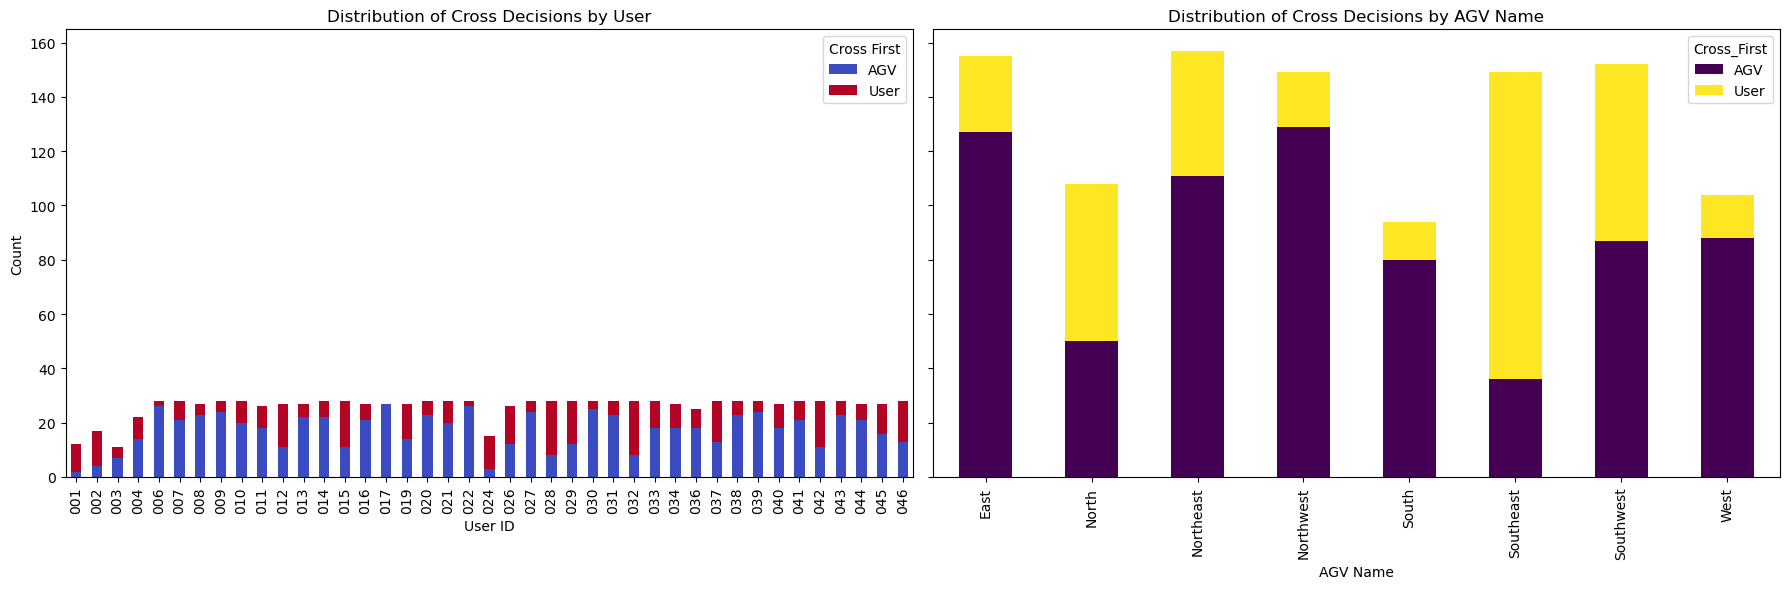

In [38]:
# Group by user and cross_first, then count
user_decision_counts = cross_first_data.groupby(['PID', 'Cross_First']).size().unstack(fill_value=0)
agv_decision_counts = cross_first_data.groupby(['AGV_Approaching', 'Cross_First']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Plot by User (PID)
user_decision_counts.plot(kind='bar', stacked=True, ax=axes[0], colormap='coolwarm')
axes[0].set_title('Distribution of Cross Decisions by User')
axes[0].set_xlabel('User ID')
axes[0].set_ylabel('Count')
axes[0].legend(title='Cross First', labels=['AGV', 'User'])

# Plot by AGVname
agv_decision_counts.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Distribution of Cross Decisions by AGV Name')
axes[1].set_xlabel('AGV Name')

plt.tight_layout()
plt.show()

Minimum distance: 130.18
Maximum distance: 3046.15


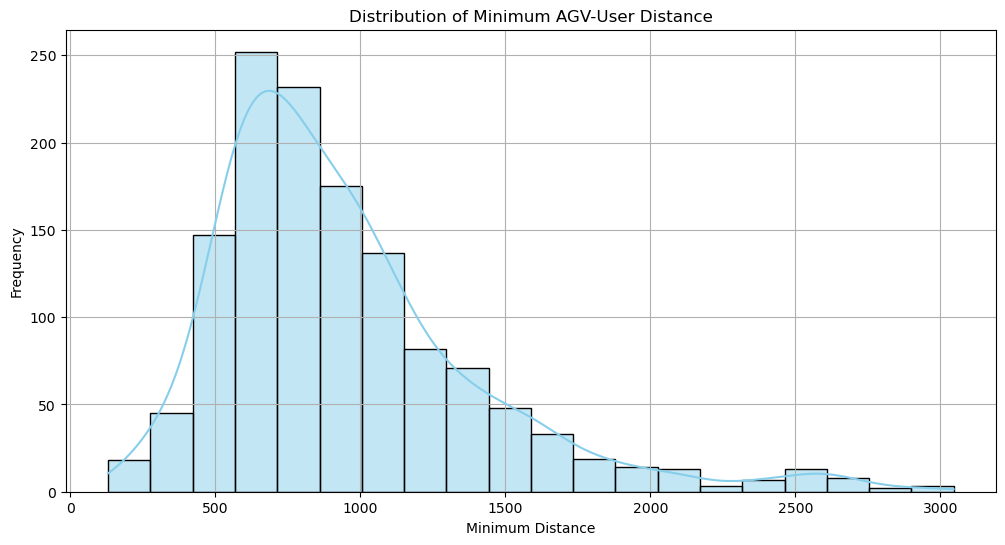

In [44]:
# Group by PID, AGVname, and DRate, then calculate the minimum value of AGV_User_distance
# min_distances = data.groupby(['PID', 'AGVname', 'DRate'])['min_dist']

# Rename the column for clarity
# min_distances.rename(columns={'AGV_User_distance': 'Min_Distance'}, inplace=True)

# Assuming `data` is your DataFrame
plt.figure(figsize=(12, 6))

# Create the histogram with KDE
sns.histplot(data=model_data, x='min_dist', bins=20, kde=True, color='skyblue')

plt.title('Distribution of Minimum AGV-User Distance')
plt.xlabel('Minimum Distance')
plt.ylabel('Frequency')
plt.grid(True)

min_value = model_data['min_dist'].min()
max_value = model_data['min_dist'].max()
print(f"Minimum distance: {min_value}")
print(f"Maximum distance: {max_value}")

# Optional: Save the plot (uncomment the following lines if needed)
# filename = f"Distribution_of_Minimum_AGV-User_Distance.png"
# full_path = os.path.join(box_path + save_dir, filename)
# plt.savefig(full_path, dpi=600)

# Show the plot
plt.show()

In [45]:
# Create a mapping dictionary from study_data
min_values = study_data.groupby(['PID', 'AGVname', 'DRate'])['AGV_User_distance'].min().to_dict()

# Assign these minimum values to the corresponding groups in model_data
model_data['AGV_User_Distance_Min'] = model_data.set_index(['PID', 'AGVname', 'DRate']).index.map(min_values)
cross_first_data['AGV_User_Distance_Min'] = cross_first_data.set_index(['PID', 'AGVname', 'DRate']).index.map(min_values)

cross_first_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Interaction No,AGV_User_Distance_Min
2,001,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,True,63.130599,120.176130,282.09,482.54,821.32,1067.08,User,3,262.097590
3,001,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,True,43.571998,263.284416,421.34,544.15,577.55,610.84,User,4,551.672375
6,001,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,True,62.064945,228.573947,379.71,540.52,665.30,941.60,User,7,598.393526
7,001,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,True,59.394993,161.124764,331.78,693.33,1038.91,1483.72,User,8,705.402875
8,001,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,True,59.041137,161.124877,115.79,379.19,541.15,1029.62,AGV,9,572.331091


In [46]:
# Convert 'StartTime' and 'EndTime' to datetime format if they are not already
cross_first_data['StartTime'] = pd.to_datetime(cross_first_data['StartTime'])
cross_first_data['EndTime'] = pd.to_datetime(cross_first_data['EndTime'])

# Create a new column 'duration' as the difference between 'EndTime' and 'StartTime'
cross_first_data['Duration'] = (cross_first_data['EndTime'] - cross_first_data['StartTime']).dt.total_seconds()

### Clustering without Dimension Reduction

In [53]:
columns = ['PID','AGVname','DRate','User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_10', 'min_dist','Duration']
features_to_scale = ['User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_10', 'min_dist', 'Duration']

In [55]:
cross_first_data = cross_first_data.dropna(subset = features_to_scale)

In [53]:
clustering_data = cross_first_data[columns].copy()

In [55]:
clustering_data.head()

,PID,AGVname,DRate,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_10,AGV_User_Distance_Min,Duration
2,001,3,High,63.130599,120.176130,1067.08,262.097590,57.0
3,001,4,High,43.571998,263.284416,610.84,551.672375,51.0
6,001,7,High,62.064945,228.573947,941.60,598.393526,43.0
7,001,8,High,59.394993,161.124764,1483.72,705.402875,61.0
8,001,9,High,59.041137,161.124877,1029.62,572.331091,61.0


In [57]:
scaler = MinMaxScaler()
scaled_features = pd.DataFrame(scaler.fit_transform(clustering_data[features_to_scale]),
                               columns=features_to_scale,
                               index=clustering_data.index)

# Preserve the other columns (e.g., the key or identifier)
other_columns = clustering_data.drop(columns=features_to_scale)

clustering_data = pd.concat([other_columns, scaled_features], axis=1)

In [59]:
clustering_data.describe()

,AGVname,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_10,AGV_User_Distance_Min,Duration
count,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000
mean,8.411985,0.267475,0.374337,0.339890,0.279379,0.197360
std,4.227452,0.128181,0.187651,0.152865,0.161433,0.106096
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.178547,0.227916,0.237503,0.169042,0.125654
50%,8.000000,0.249435,0.350498,0.329567,0.240932,0.178010
75%,12.000000,0.329066,0.500558,0.430003,0.342715,0.251309
max,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [61]:
print("First five elements of clustering_data are:\n", clustering_data[:5]) 
print('The shape of clustering_data is:', clustering_data.shape)

First five elements of clustering_data are:
    PID  AGVname DRate  User_Relative_Speed  AGV_Relative_Speed  \
2  001        3  High             0.269346            0.245112   
3  001        4  High             0.156120            0.638370   
6  001        7  High             0.263176            0.542987   
7  001        8  High             0.247720            0.357638   
8  001        9  High             0.245672            0.357638   

   Frechet_Distance_10  AGV_User_Distance_Min  Duration  
2             0.360337               0.044412  0.183246  
3             0.206271               0.143750  0.151832  
6             0.317964               0.159778  0.109948  
7             0.501030               0.196488  0.204188  
8             0.347687               0.150837  0.204188  
The shape of clustering_data is: (1068, 8)


C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

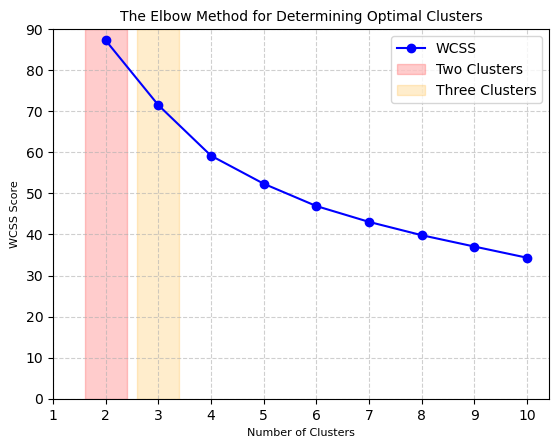

In [63]:
# Applying Elbow method on WCSS score to find ideal K(number of clusters) value.
# Determining the number of clusters
ssd = []  # Within-cluster sum of squares
sscore = []
for i in range(2, 11):  # Test from 1 to `k` clusters
    kmeans = KMeans(n_clusters = i, init = "k-means++", n_init = 11, max_iter = 300, random_state = 0)
    kmeans.fit(clustering_data[features_to_scale])
    ssd.append([i, kmeans.inertia_])
    ss = silhouette_score(clustering_data[features_to_scale], kmeans.labels_)
    sscore.append([i, ss])
    
pd.DataFrame(ssd).plot(x = 0, y = 1, marker='o', linestyle='-', color='b', label='WCSS')
# Adding shaded regions with axvspan
plt.axvspan(1.6, 2.4, color='red', alpha=0.2, label="Two Clusters")
plt.axvspan(2.6, 3.4, color='orange', alpha=0.2, label="Three Clusters")

# Adding labels and titles
plt.xlabel('Number of Clusters', fontsize=8)
plt.ylabel('WCSS Score', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="best")
plt.xticks(range(1, 11))  # Set x-axis ticks from 1 to 10
plt.yticks(range(0, 100, 10))
plt.title("The Elbow Method for Determining Optimal Clusters", fontsize = 10)

filename = "The_Elbow_Method_for_Determining_Optimal_Clusters.png"
full_path = os.path.join(box_path + save_dir, filename)
# plt.savefig(full_path, dpi=300)
plt.show()

In [65]:
# training the model with multiple values of n_clusters (value of k) and calculating the wcss (used to implement the elbow method)
wcss = []
n_grps = list(range(2, 21))   # 1 to 10

# training  multiple models
for i in n_grps:
  k_model = KMeans(n_clusters = i, n_init = 10, init = 'k-means++', random_state = 20)
  k_model.fit(clustering_data[features_to_scale])
  wcss.append(k_model.inertia_)

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

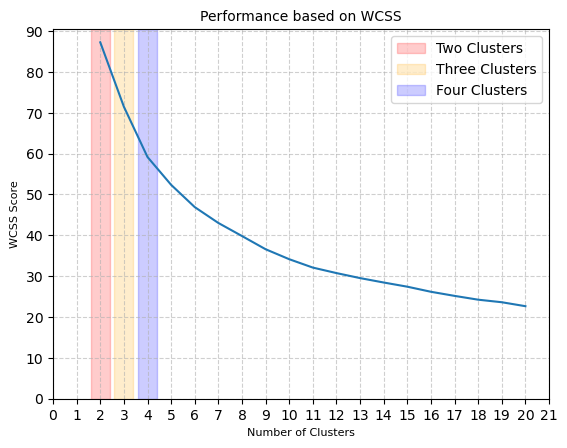

In [67]:
# visualizing the performance
plt.plot(n_grps, wcss)
plt.axvspan(1.6, 2.4, color='red', alpha=0.2, label="Two Clusters")
plt.axvspan(2.6, 3.4, color='orange', alpha=0.2, label="Three Clusters")
plt.axvspan(3.6, 4.4, color='blue', alpha=0.2, label="Four Clusters")

# Adding labels and titles
plt.xlabel('Number of Clusters', fontsize=8)
plt.ylabel('WCSS Score', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="best")
plt.xticks(range(0, 22))  # Set x-axis ticks from 1 to 10
plt.yticks(range(0, 100, 10))
plt.title("Performance based on WCSS", fontsize = 10)
plt.show()

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

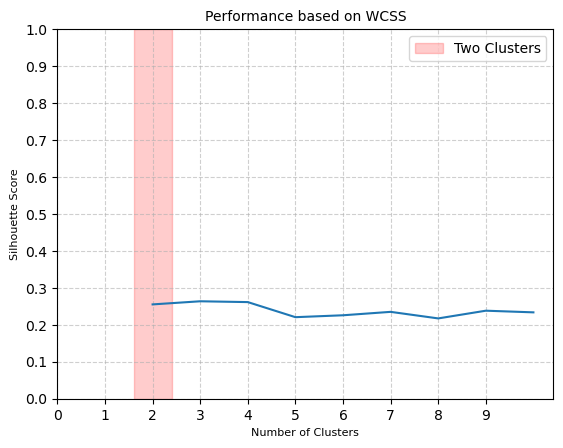

In [69]:
error=np.zeros(11)
sh_score=np.zeros(11)
for k in range(1,11):
    kmeans=sk_cluster.KMeans(init='k-means++', n_clusters=k,n_init=10)
    kmeans.fit_predict(clustering_data[features_to_scale])
    error[k]=kmeans.inertia_
    if k>1: sh_score[k] = metrics.silhouette_score(clustering_data[features_to_scale], kmeans.labels_)
plt.plot(range(2,len(sh_score)),sh_score[2:])

plt.axvspan(1.6, 2.4, color='red', alpha=0.2, label="Two Clusters")
# plt.axvspan(2.6, 3.4, color='orange', alpha=0.2, label="Three Clusters")
# plt.axvspan(3.6, 4.4, color='red', alpha=0.2, label="Four Clusters")


# Adding labels and titles
plt.xlabel('Number of Clusters', fontsize=8)
plt.ylabel('Silhouette Score', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="best")
plt.xticks(range(0, 10))  # Set x-axis ticks from 1 to 10
plt.yticks(np.arange(0, 1.1, 0.1))
plt.title("Performance based on WCSS", fontsize = 10)
plt.show()

In [71]:
# creating k_model with 4 clusters
k_model = KMeans(n_clusters = 2, n_init = 10, init = 'k-means++', random_state = 20)
clusters = k_model.fit_predict(clustering_data[features_to_scale])
clusters

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


array([0, 1, 1, ..., 1, 1, 1])

In [73]:
# appending the clusters assignment to the dataframe
clustering_data['Kcluster'] = clusters
clustering_data.head()

,PID,AGVname,DRate,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_10,AGV_User_Distance_Min,Duration,Kcluster
2,001,3,High,0.269346,0.245112,0.360337,0.044412,0.183246,0
3,001,4,High,0.156120,0.638370,0.206271,0.143750,0.151832,1
6,001,7,High,0.263176,0.542987,0.317964,0.159778,0.109948,1
7,001,8,High,0.247720,0.357638,0.501030,0.196488,0.204188,1
8,001,9,High,0.245672,0.357638,0.347687,0.150837,0.204188,1


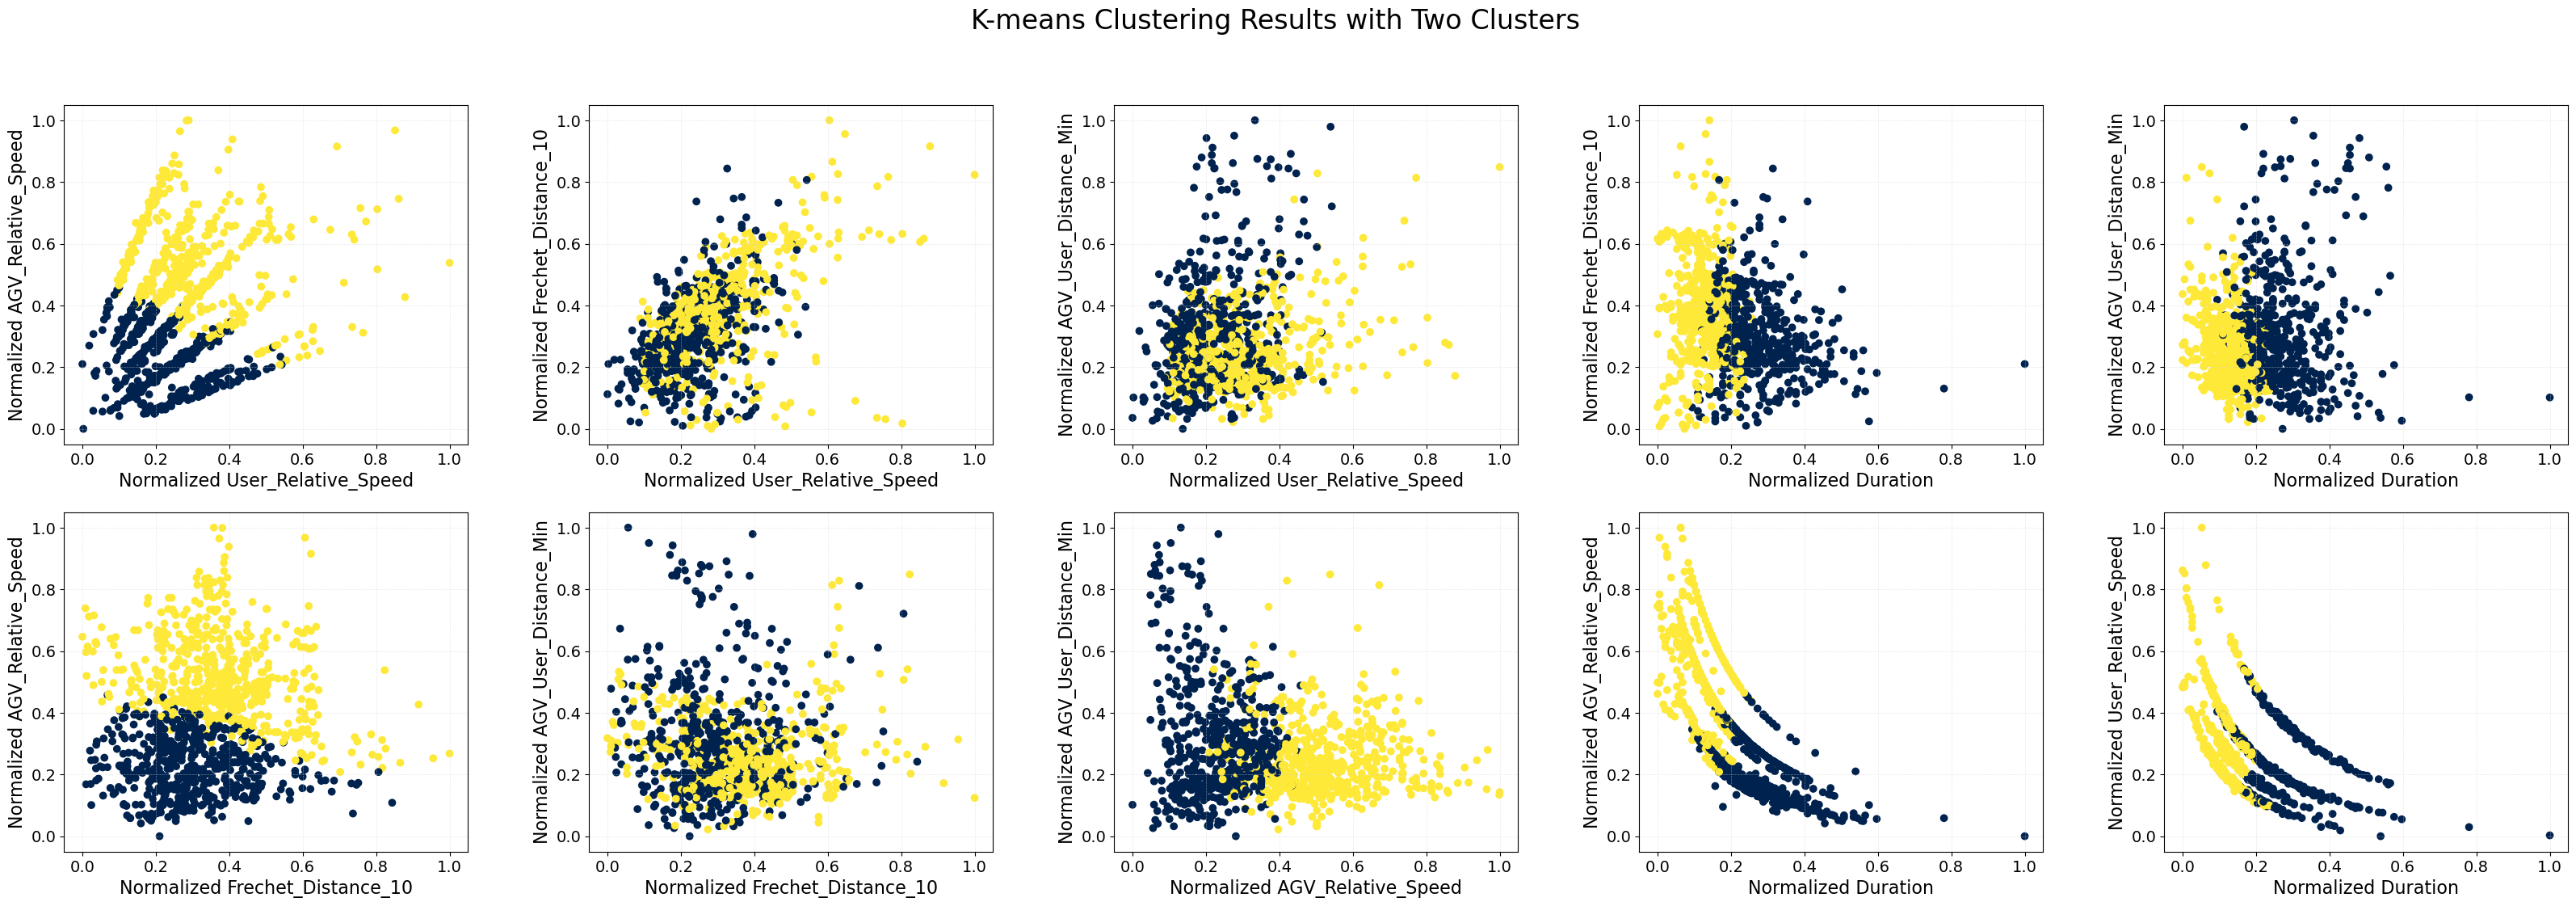

In [168]:
fig, axs = plt.subplots(2, 5, figsize=(40, 12), sharex=False)


axs[0, 0].scatter(clustering_data['User_Relative_Speed'], clustering_data['AGV_Relative_Speed'], 
               c=clustering_data['Kcluster'], cmap = 'cividis')
axs[0, 0].set_xlabel('Normalized User_Relative_Speed', fontsize=16)
axs[0, 0].set_ylabel('Normalized AGV_Relative_Speed', fontsize=16)
axs[0, 0].tick_params(axis='both', which='major', labelsize=14)
axs[0, 0].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[0, 1].scatter(clustering_data['User_Relative_Speed'], clustering_data['Frechet_Distance_10'], 
               c=clustering_data['Kcluster'], cmap = 'cividis')
axs[0, 1].set_xlabel('Normalized User_Relative_Speed', fontsize=16)
axs[0, 1].set_ylabel('Normalized Frechet_Distance_10', fontsize=16)
axs[0, 1].tick_params(axis='both', which='major', labelsize=14)
axs[0, 1].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[0, 2].scatter(clustering_data['User_Relative_Speed'], clustering_data['AGV_User_Distance_Min'], 
               c=clustering_data['Kcluster'], cmap = 'cividis')
axs[0, 2].set_xlabel('Normalized User_Relative_Speed', fontsize=16)
axs[0, 2].set_ylabel('Normalized AGV_User_Distance_Min', fontsize=16)
axs[0, 2].tick_params(axis='both', which='major', labelsize=14)
axs[0, 2].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)

axs[0, 3].scatter(clustering_data['Duration'], clustering_data['Frechet_Distance_10'], 
               c=clustering_data['Kcluster'], cmap = 'cividis')
axs[0, 3].set_xlabel('Normalized Duration', fontsize=16)
axs[0, 3].set_ylabel('Normalized Frechet_Distance_10', fontsize=16)
axs[0, 3].tick_params(axis='both', which='major', labelsize=14)
axs[0, 3].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[0, 4].scatter(clustering_data['Duration'], clustering_data['AGV_User_Distance_Min'], 
               c=clustering_data['Kcluster'], cmap = 'cividis')
axs[0, 4].set_xlabel('Normalized Duration', fontsize=16)
axs[0, 4].set_ylabel('Normalized AGV_User_Distance_Min', fontsize=16)
axs[0, 4].tick_params(axis='both', which='major', labelsize=14)
axs[0, 4].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[1, 0].scatter(clustering_data['Frechet_Distance_10'], clustering_data['AGV_Relative_Speed'], 
               c=clustering_data['Kcluster'], cmap = 'cividis')
axs[1, 0].set_xlabel('Normalized Frechet_Distance_10', fontsize=16)
axs[1, 0].set_ylabel('Normalized AGV_Relative_Speed', fontsize=16)
axs[1, 0].tick_params(axis='both', which='major', labelsize=14)
axs[1, 0].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[1, 1].scatter(clustering_data['Frechet_Distance_10'], clustering_data['AGV_User_Distance_Min'], 
               c=clustering_data['Kcluster'], cmap = 'cividis')
axs[1, 1].set_xlabel('Normalized Frechet_Distance_10', fontsize=16)
axs[1, 1].set_ylabel('Normalized AGV_User_Distance_Min', fontsize=16)
axs[1, 1].tick_params(axis='both', which='major', labelsize=14)
axs[1, 1].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[1, 2].scatter(clustering_data['AGV_Relative_Speed'], clustering_data['AGV_User_Distance_Min'], 
               c=clustering_data['Kcluster'], cmap = 'cividis')
axs[1, 2].set_xlabel('Normalized AGV_Relative_Speed', fontsize=16)
axs[1, 2].set_ylabel('Normalized AGV_User_Distance_Min', fontsize=16)
axs[1, 2].tick_params(axis='both', which='major', labelsize=14)
axs[1, 2].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)

axs[1, 3].scatter(clustering_data['Duration'], clustering_data['AGV_Relative_Speed'], 
               c=clustering_data['Kcluster'], cmap = 'cividis')
axs[1, 3].set_xlabel('Normalized Duration', fontsize=16)
axs[1, 3].set_ylabel('Normalized AGV_Relative_Speed', fontsize=16)
axs[1, 3].tick_params(axis='both', which='major', labelsize=14)
axs[1, 3].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[1, 4].scatter(clustering_data['Duration'], clustering_data['User_Relative_Speed'], 
               c=clustering_data['Kcluster'], cmap = 'cividis')
axs[1, 4].set_xlabel('Normalized Duration', fontsize=16)
axs[1, 4].set_ylabel('Normalized User_Relative_Speed', fontsize=16)
axs[1, 4].tick_params(axis='both', which='major', labelsize=14)
axs[1, 4].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)

# Adjust layout
plt.subplots_adjust(wspace=0.3)
plt.suptitle("K-means Clustering Results with Two Clusters", fontsize=24)

filename = f'K-means_Clustering_Results_with_Two_Clusters.png'
full_path = os.path.join(box_path + save_dir, filename) 
plt.savefig(full_path, dpi=300)

plt.show()

### DB-Scan Clustering

In [79]:
# training different models and choosing the one with best silhouette score
epss = [1, 2, 3, 4, 5]
n_min_smpls = [1, 2, 3, 4, 5]
results = []

# training multiple models with different values of eps and  min_samples
for eps in epss:
  for smpls in n_min_smpls:
    db_model = DBSCAN(eps = eps, min_samples = smpls)
    db_model.fit(clustering_data[features_to_scale])
    try:
      score = silhouette_score(clustering_data[features_to_scale], db_model.labels_)
      results.append([eps, smpls, score])
    except:
      results.append([eps, smpls, 0])


# creating a dataframe from the results and sorting using score and displaying head
db_df = pd.DataFrame(results, columns = ['Epsilon', 'Min_samples', 'Score'])
db_df = db_df.sort_values(by = 'Score', ascending = False).reset_index()
db_df.head()

,index,Epsilon,Min_samples,Score
0,0,1,1,0
1,13,3,4,0
2,23,5,4,0
3,22,5,3,0
4,21,5,2,0


In [81]:
# creating and training a DBSCAN model for the specified model
db_model = DBSCAN(eps = 3, min_samples = 3)
db_model.fit(clustering_data[features_to_scale])
db_model.labels_

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

<Axes: xlabel='User_Relative_Speed', ylabel='AGV_Relative_Speed'>

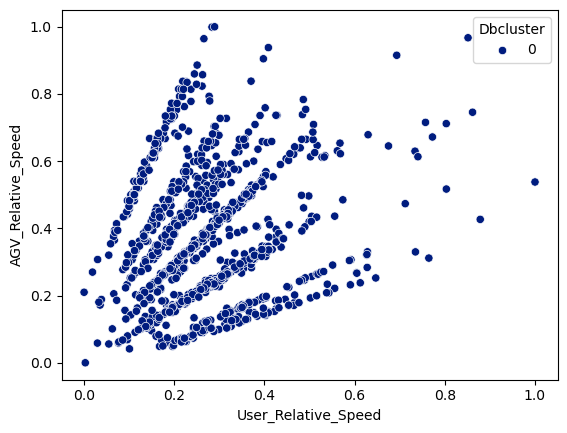

In [85]:
# adding the results in the df
clustering_data['Dbcluster'] = db_model.labels_
# visulaizing the clusters
sns.scatterplot(data = clustering_data, x = 'User_Relative_Speed', y = 'AGV_Relative_Speed', hue = 'Dbcluster', palette = 'dark')

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\1878058417.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(title='Db-cluster', fontsize=10)
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\1878058417.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(title='Db-cluster', fontsize=10)
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\1878058417.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend(title='Db-cluster', fontsize=10)


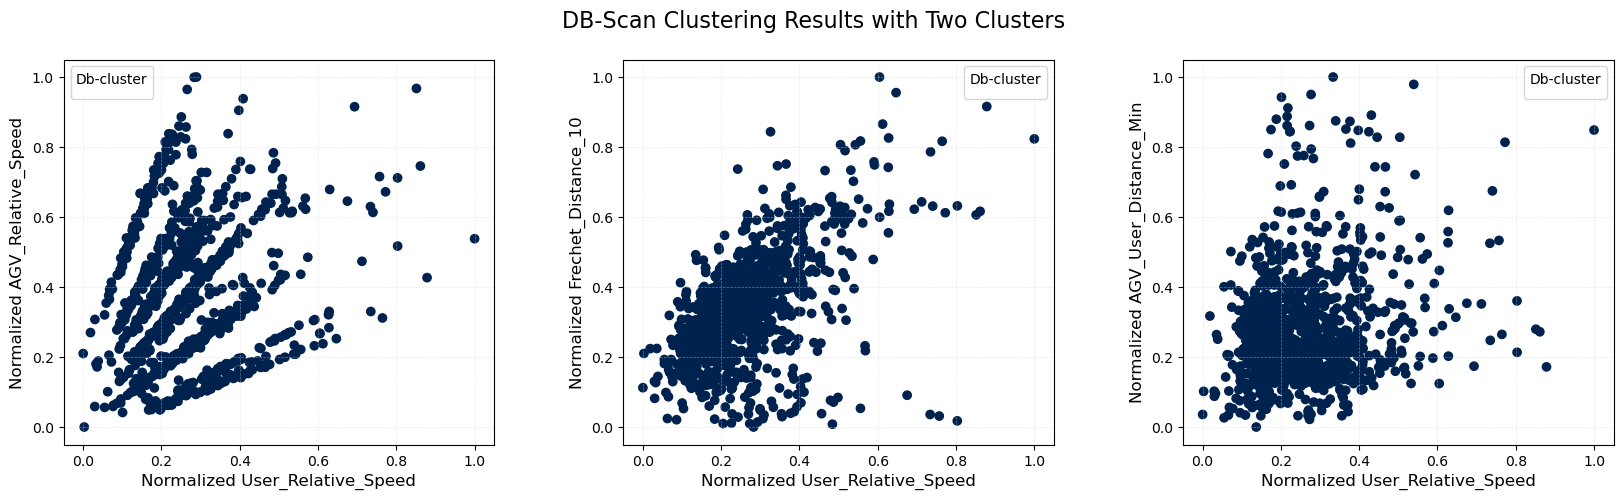

In [87]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=False)

# AGV_Relative_Speed
axs[0].scatter(clustering_data['User_Relative_Speed'], clustering_data['AGV_Relative_Speed'], 
               c=clustering_data['Dbcluster'], cmap = 'cividis')
axs[0].set_xlabel('Normalized User_Relative_Speed', fontsize=12)
axs[0].set_ylabel('Normalized AGV_Relative_Speed', fontsize=12)
axs[0].tick_params(axis='both', which='major', labelsize=10)
axs[0].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0].legend(title='Db-cluster', fontsize=10)

# Frechet_Distance_10
axs[1].scatter(clustering_data['User_Relative_Speed'], clustering_data['Frechet_Distance_10'], 
               c=clustering_data['Dbcluster'], cmap = 'cividis')
axs[1].set_xlabel('Normalized User_Relative_Speed', fontsize=12)
axs[1].set_ylabel('Normalized Frechet_Distance_10', fontsize=12)
axs[1].tick_params(axis='both', which='major', labelsize=10)
axs[1].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)
axs[1].legend(title='Db-cluster', fontsize=10)

# AGV_User_Distance_Min
axs[2].scatter(clustering_data['User_Relative_Speed'], clustering_data['AGV_User_Distance_Min'], 
               c=clustering_data['Dbcluster'], cmap = 'cividis')
axs[2].set_xlabel('Normalized User_Relative_Speed', fontsize=12)
axs[2].set_ylabel('Normalized AGV_User_Distance_Min', fontsize=12)
axs[2].tick_params(axis='both', which='major', labelsize=10)
axs[2].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)
axs[2].legend(title='Db-cluster', fontsize=10)

# Adjust layout
plt.subplots_adjust(wspace=0.3)
plt.suptitle("DB-Scan Clustering Results with Two Clusters", fontsize=16)

filename = f'DB-Scan_Clustering_Results_with_Two_Clusters.png'
full_path = os.path.join(box_path + save_dir, filename) 
# plt.savefig(full_path, dpi=300)

plt.show()

### Agglomerative Clustering

In [90]:
# creating multiple models and computing silhouette score, appending details to results and sorting the results df
results = []
n_grps = list(range(2, 21))

for n in n_grps:
  hr_model = AgglomerativeClustering(n_clusters = n)
  hr_model.fit(clustering_data[features_to_scale])
  try:
    score = silhouette_score(clustering_data[features_to_scale], hr_model.labels_)
    results.append([n, score])
  except:
    results.append([n, score])

# creating df from results
df_hr = pd.DataFrame(results, columns = ['N_clusters', 'Score'])
df_hr = df_hr.sort_values(by = 'Score', ascending = False).reset_index(drop = True)
df_hr.head()

,N_clusters,Score
0,2,0.207617
1,6,0.202716
2,5,0.200918
3,4,0.198420
4,11,0.195383


#### We got highest score with 2 clusters. Let's train the final hr_model and visualize the clusters.

In [93]:
# training the model
hr_model = AgglomerativeClustering(n_clusters = 2, linkage='single')
hr_model.fit(clustering_data[features_to_scale])
hr_model.labels_

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

<Axes: xlabel='User_Relative_Speed', ylabel='AGV_Relative_Speed'>

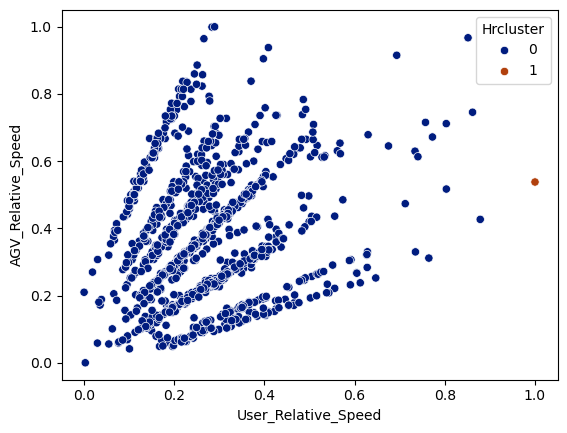

In [95]:
# adding cluster results to df and visualizing
clustering_data['Hrcluster'] = hr_model.labels_
sns.scatterplot(data = clustering_data, x = 'User_Relative_Speed', y = 'AGV_Relative_Speed', hue = 'Hrcluster', palette = 'dark')

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\1937322091.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(title='Hr-cluster', fontsize=10)
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\1937322091.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(title='Hr-cluster', fontsize=10)
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\1937322091.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend(title='Hr-cluster', fontsize=10)


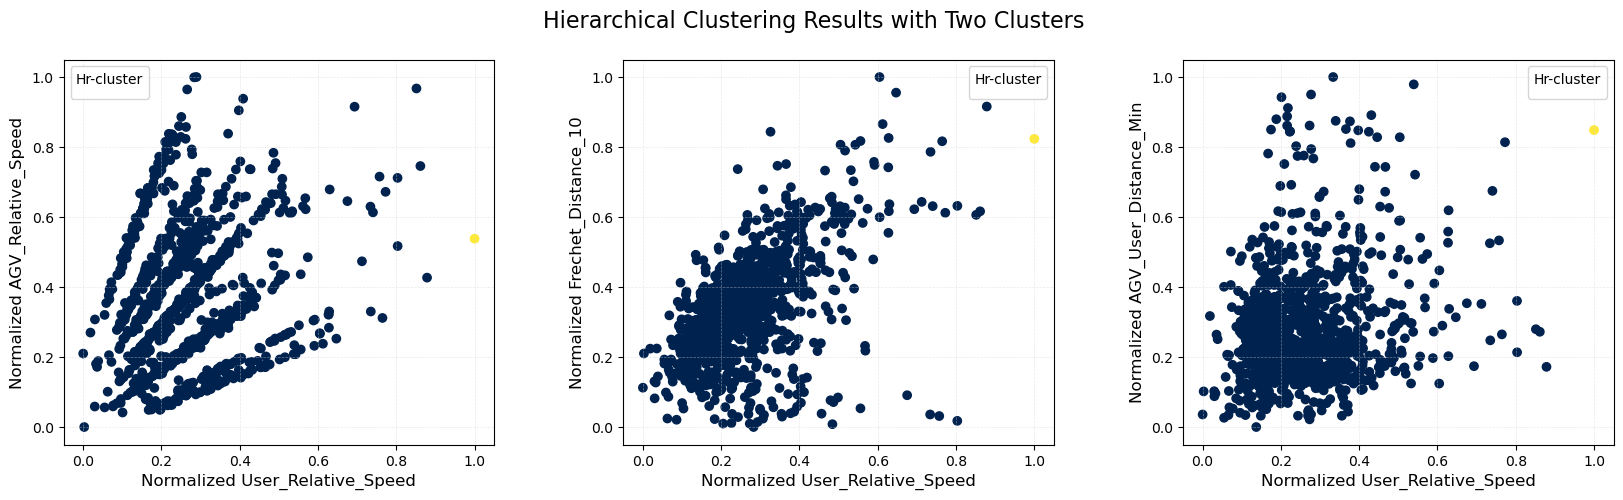

In [97]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=False)

# AGV_Relative_Speed
axs[0].scatter(clustering_data['User_Relative_Speed'], clustering_data['AGV_Relative_Speed'], 
               c=clustering_data['Hrcluster'], cmap = 'cividis')
axs[0].set_xlabel('Normalized User_Relative_Speed', fontsize=12)
axs[0].set_ylabel('Normalized AGV_Relative_Speed', fontsize=12)
axs[0].tick_params(axis='both', which='major', labelsize=10)
axs[0].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0].legend(title='Hr-cluster', fontsize=10)

# Frechet_Distance_10
axs[1].scatter(clustering_data['User_Relative_Speed'], clustering_data['Frechet_Distance_10'], 
               c=clustering_data['Hrcluster'], cmap = 'cividis')
axs[1].set_xlabel('Normalized User_Relative_Speed', fontsize=12)
axs[1].set_ylabel('Normalized Frechet_Distance_10', fontsize=12)
axs[1].tick_params(axis='both', which='major', labelsize=10)
axs[1].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)
axs[1].legend(title='Hr-cluster', fontsize=10)

# AGV_User_Distance_Min
axs[2].scatter(clustering_data['User_Relative_Speed'], clustering_data['AGV_User_Distance_Min'], 
               c=clustering_data['Hrcluster'], cmap = 'cividis')
axs[2].set_xlabel('Normalized User_Relative_Speed', fontsize=12)
axs[2].set_ylabel('Normalized AGV_User_Distance_Min', fontsize=12)
axs[2].tick_params(axis='both', which='major', labelsize=10)
axs[2].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)
axs[2].legend(title='Hr-cluster', fontsize=10)

# Adjust layout
plt.subplots_adjust(wspace=0.3)
plt.suptitle("Hierarchical Clustering Results with Two Clusters", fontsize=16)

filename = f'Hierarchical_Clustering_Results_with_Two_Clusters.png'
full_path = os.path.join(box_path + save_dir, filename) 
# plt.savefig(full_path, dpi=300)

plt.show()

### Gaussian Mixtures

In [100]:
# Step 1: Evaluate silhouette scores for different numbers of clusters
results = []
n_clusters_range = range(2, 11)  # Testing clusters from 2 to 10
for n in n_clusters_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(clustering_data[features_to_scale])
    labels = gmm.predict(clustering_data[features_to_scale])
    score = silhouette_score(clustering_data[features_to_scale], labels)
    results.append((n, score))

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

In [102]:
# Step 2: Create a DataFrame for results and find the optimal number of clusters
df_gm = pd.DataFrame(results, columns=['N_clusters', 'Score'])
df_gm = df_gm.sort_values(by='Score', ascending=False).reset_index(drop=True)
df_gm.head()

,N_clusters,Score
0,2,0.238304
1,5,0.186717
2,3,0.181086
3,4,0.180806
4,10,0.140620


In [104]:
# Optimal number of clusters
optimal_clusters = df_gm.iloc[0]['N_clusters']

In [106]:
# Step 3: Train Gaussian Mixture Model with the optimal number of clusters
gmm = GaussianMixture(n_components=int(optimal_clusters), random_state=42)
gmm.fit(clustering_data[features_to_scale])
labels = gmm.predict(clustering_data[features_to_scale])

C:\Users\HIALAB\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


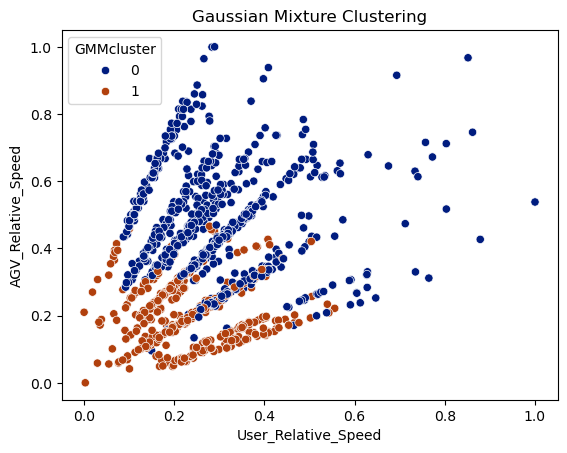

In [110]:
# Step 4: Add cluster labels to the dataset
clustering_data['GMMcluster'] = labels

# Step 5: Visualize the clusters
sns.scatterplot(
    data=clustering_data,
    x='User_Relative_Speed',
    y='AGV_Relative_Speed',
    hue='GMMcluster',
    palette='dark'
)
plt.xlabel('User_Relative_Speed')
plt.ylabel('AGV_Relative_Speed')
plt.title('Gaussian Mixture Clustering')
plt.show()

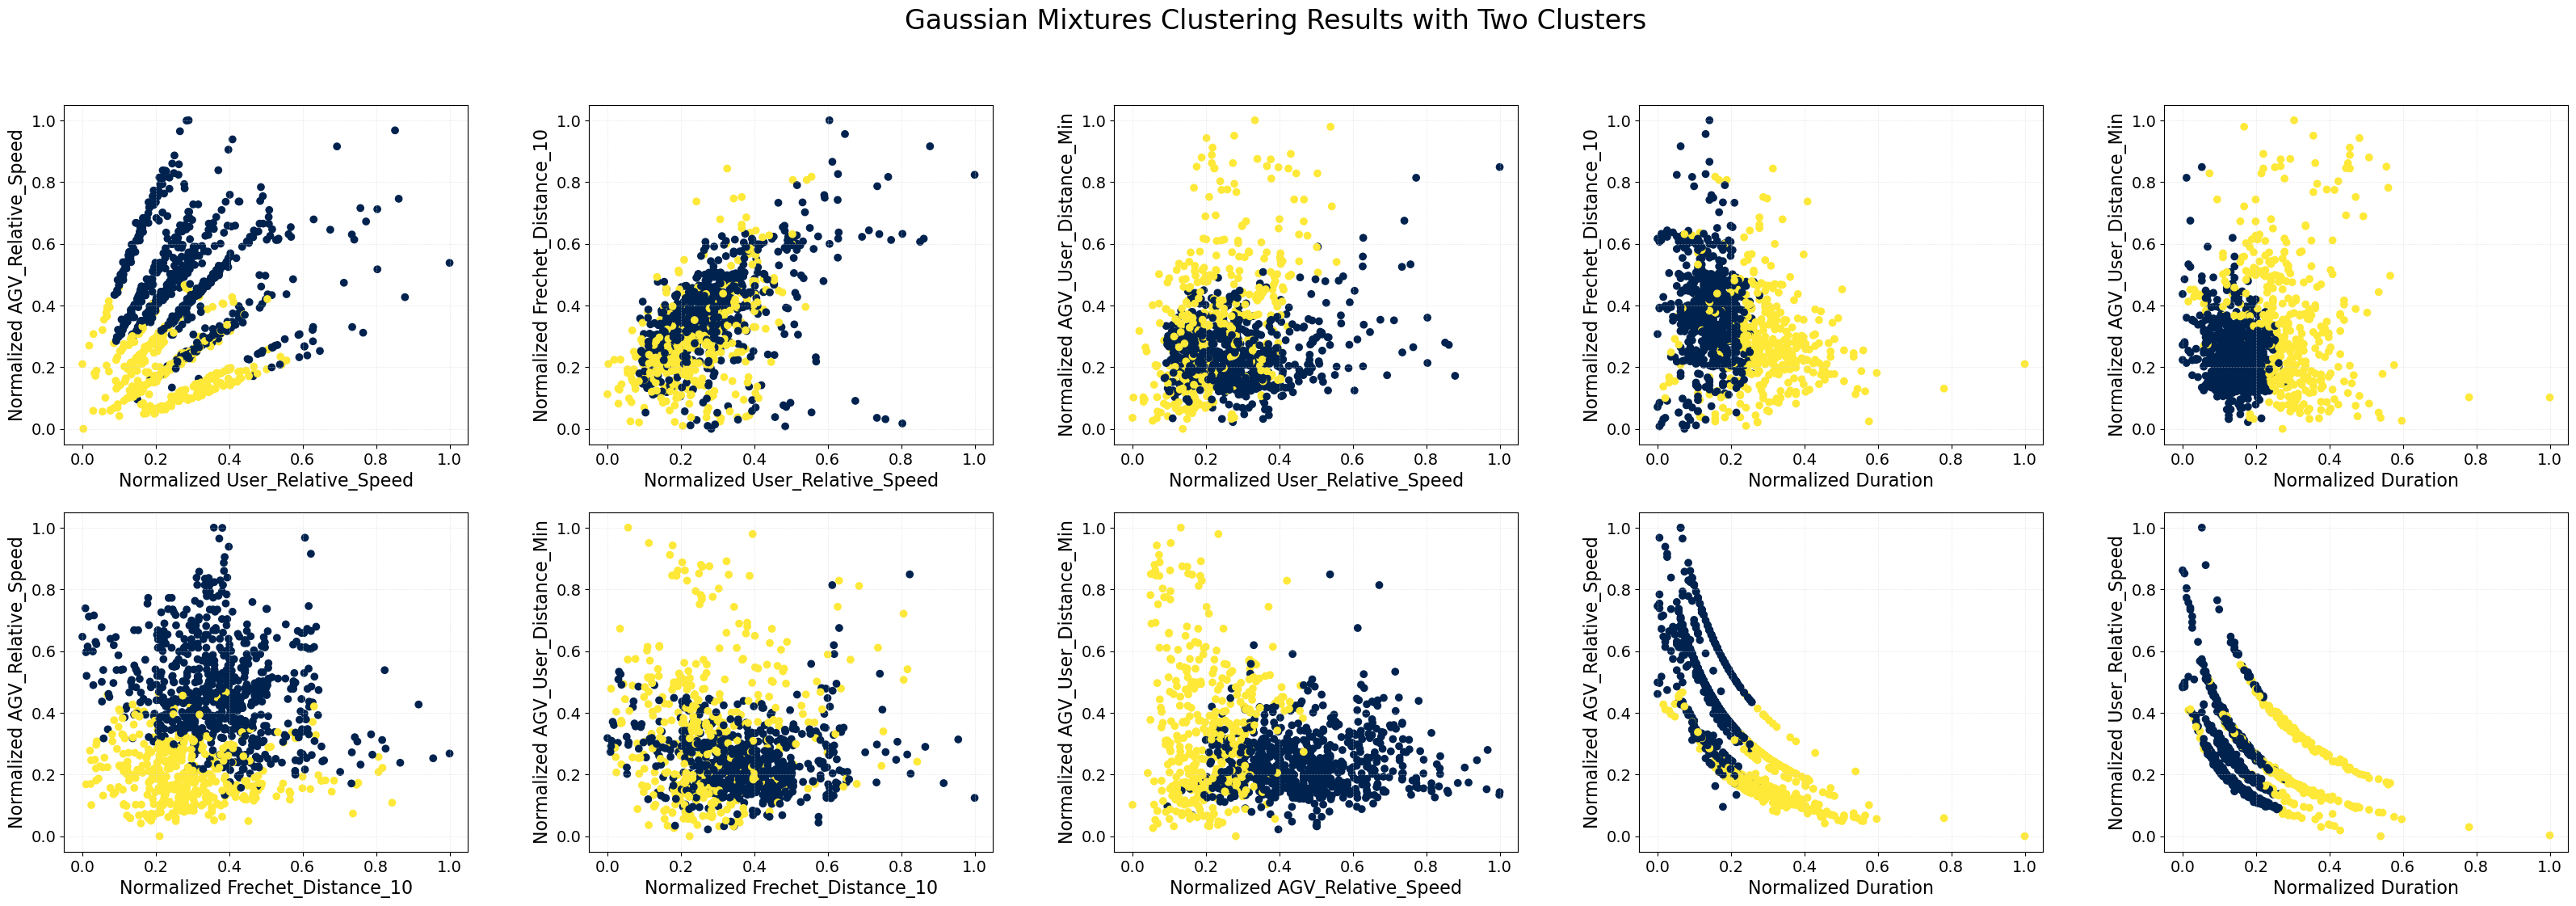

In [170]:
fig, axs = plt.subplots(2, 5, figsize=(40, 12), sharex=False)

axs[0, 0].scatter(clustering_data['User_Relative_Speed'], clustering_data['AGV_Relative_Speed'], 
               c=clustering_data['GMMcluster'], cmap = 'cividis')
axs[0, 0].set_xlabel('Normalized User_Relative_Speed', fontsize=16)
axs[0, 0].set_ylabel('Normalized AGV_Relative_Speed', fontsize=16)
axs[0, 0].tick_params(axis='both', which='major', labelsize=14)
axs[0, 0].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[0, 1].scatter(clustering_data['User_Relative_Speed'], clustering_data['Frechet_Distance_10'], 
               c=clustering_data['GMMcluster'], cmap = 'cividis')
axs[0, 1].set_xlabel('Normalized User_Relative_Speed', fontsize=16)
axs[0, 1].set_ylabel('Normalized Frechet_Distance_10', fontsize=16)
axs[0, 1].tick_params(axis='both', which='major', labelsize=14)
axs[0, 1].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[0, 2].scatter(clustering_data['User_Relative_Speed'], clustering_data['AGV_User_Distance_Min'], 
               c=clustering_data['GMMcluster'], cmap = 'cividis')
axs[0, 2].set_xlabel('Normalized User_Relative_Speed', fontsize=16)
axs[0, 2].set_ylabel('Normalized AGV_User_Distance_Min', fontsize=16)
axs[0, 2].tick_params(axis='both', which='major', labelsize=14)
axs[0, 2].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)

axs[0, 3].scatter(clustering_data['Duration'], clustering_data['Frechet_Distance_10'], 
               c=clustering_data['GMMcluster'], cmap = 'cividis')
axs[0, 3].set_xlabel('Normalized Duration', fontsize=16)
axs[0, 3].set_ylabel('Normalized Frechet_Distance_10', fontsize=16)
axs[0, 3].tick_params(axis='both', which='major', labelsize=14)
axs[0, 3].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[0, 4].scatter(clustering_data['Duration'], clustering_data['AGV_User_Distance_Min'], 
               c=clustering_data['GMMcluster'], cmap = 'cividis')
axs[0, 4].set_xlabel('Normalized Duration', fontsize=16)
axs[0, 4].set_ylabel('Normalized AGV_User_Distance_Min', fontsize=16)
axs[0, 4].tick_params(axis='both', which='major', labelsize=14)
axs[0, 4].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)

axs[1, 0].scatter(clustering_data['Frechet_Distance_10'], clustering_data['AGV_Relative_Speed'], 
               c=clustering_data['GMMcluster'], cmap = 'cividis')
axs[1, 0].set_xlabel('Normalized Frechet_Distance_10', fontsize=16)
axs[1, 0].set_ylabel('Normalized AGV_Relative_Speed', fontsize=16)
axs[1, 0].tick_params(axis='both', which='major', labelsize=14)
axs[1, 0].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[1, 1].scatter(clustering_data['Frechet_Distance_10'], clustering_data['AGV_User_Distance_Min'], 
               c=clustering_data['GMMcluster'], cmap = 'cividis')
axs[1, 1].set_xlabel('Normalized Frechet_Distance_10', fontsize=16)
axs[1, 1].set_ylabel('Normalized AGV_User_Distance_Min', fontsize=16)
axs[1, 1].tick_params(axis='both', which='major', labelsize=14)
axs[1, 1].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[1, 2].scatter(clustering_data['AGV_Relative_Speed'], clustering_data['AGV_User_Distance_Min'], 
               c=clustering_data['GMMcluster'], cmap = 'cividis')
axs[1, 2].set_xlabel('Normalized AGV_Relative_Speed', fontsize=16)
axs[1, 2].set_ylabel('Normalized AGV_User_Distance_Min', fontsize=16)
axs[1, 2].tick_params(axis='both', which='major', labelsize=14)
axs[1, 2].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)

axs[1, 3].scatter(clustering_data['Duration'], clustering_data['AGV_Relative_Speed'], 
               c=clustering_data['GMMcluster'], cmap = 'cividis')
axs[1, 3].set_xlabel('Normalized Duration', fontsize=16)
axs[1, 3].set_ylabel('Normalized AGV_Relative_Speed', fontsize=16)
axs[1, 3].tick_params(axis='both', which='major', labelsize=14)
axs[1, 3].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)


axs[1, 4].scatter(clustering_data['Duration'], clustering_data['User_Relative_Speed'], 
               c=clustering_data['GMMcluster'], cmap = 'cividis')
axs[1, 4].set_xlabel('Normalized Duration', fontsize=16)
axs[1, 4].set_ylabel('Normalized User_Relative_Speed', fontsize=16)
axs[1, 4].tick_params(axis='both', which='major', labelsize=14)
axs[1, 4].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)

# Adjust layout
plt.subplots_adjust(wspace=0.3)
plt.suptitle("Gaussian Mixtures Clustering Results with Two Clusters", fontsize=24)

filename = f'Gaussian-Mixtures_Clustering_Results_with_Two_Clusters.png'
full_path = os.path.join(box_path + save_dir, filename) 
plt.savefig(full_path, dpi=300)

plt.show()

#### Since K-Means and Gaussian Mixtures Clustering look promising, we will do data analysis with respect to those.

In [116]:
clustering_data.head()

,PID,AGVname,DRate,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_10,AGV_User_Distance_Min,Duration,Kcluster,Dbcluster,Hrcluster,GMMcluster
2,001,3,High,0.269346,0.245112,0.360337,0.044412,0.183246,0,0,0,1
3,001,4,High,0.156120,0.638370,0.206271,0.143750,0.151832,1,0,0,0
6,001,7,High,0.263176,0.542987,0.317964,0.159778,0.109948,1,0,0,0
7,001,8,High,0.247720,0.357638,0.501030,0.196488,0.204188,1,0,0,0
8,001,9,High,0.245672,0.357638,0.347687,0.150837,0.204188,1,0,0,0


In [118]:
cross_first_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Interaction No,AGV_User_Distance_Min,Duration
2,001,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,63.130599,120.176130,282.09,482.54,821.32,1067.08,User,3,262.097590,57.0
3,001,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,43.571998,263.284416,421.34,544.15,577.55,610.84,User,4,551.672375,51.0
6,001,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,62.064945,228.573947,379.71,540.52,665.30,941.60,User,7,598.393526,43.0
7,001,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,59.394993,161.124764,331.78,693.33,1038.91,1483.72,User,8,705.402875,61.0
8,001,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,59.041137,161.124877,115.79,379.19,541.15,1029.62,AGV,9,572.331091,61.0


In [120]:
print("clustering_data columns:", clustering_data.columns)
print("cross_first_data columns:", cross_first_data.columns)

clustering_data columns: Index(['PID', 'AGVname', 'DRate', 'User_Relative_Speed', 'AGV_Relative_Speed',
       'Frechet_Distance_10', 'AGV_User_Distance_Min', 'Duration', 'Kcluster',
       'Dbcluster', 'Hrcluster', 'GMMcluster'],
      dtype='object')
cross_first_data columns: Index(['PID', 'DRate', 'date', 'hr', 'min', 's', 'AGVname', 'StartTime',
       'EndTime', 'GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd',
       'task', 'Trust', 'Safe', 'Comfort', 'Expect', 'Age', 'Gender',
       'Ethnicity', 'GamingFrequency', 'VRExperience', 'VRHeadsetExperience',
       'AGVInteraction', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience', 'Trust1', 'Trust2', 'MWL', 'Assessment',
       'Gaze_on_AGV', 'User_Trajectory', 'AGV_Approaching',
       'AGV_User_Combination', 'AGV_Path_Complexity', 'Trust_before',
       'Cross_First_Flag', 'User_Relative_Speed', 'AGV_Relative_Speed',
       'Freche

In [122]:
clustering_data['PID'] = clustering_data['PID'].apply(lambda x: str(x).zfill(3))
cross_first_data['PID'] = cross_first_data['PID'].apply(lambda x: str(x).zfill(3))

In [124]:
temp_merge = clustering_data[['PID', 'AGVname', 'DRate']]
print(temp_merge.head())

   PID  AGVname DRate
2  001        3  High
3  001        4  High
6  001        7  High
7  001        8  High
8  001        9  High


In [126]:
# Round the columns to ensure precision matches
columns_to_match = ['PID', 'AGVname', 'DRate']
clustering_data[columns_to_match] = clustering_data[columns_to_match].round(1)
cross_first_data[columns_to_match] = cross_first_data[columns_to_match].round(1)

# Perform the merge
cross_first_data = cross_first_data.merge(
    clustering_data[['PID', 'AGVname', 'DRate', 'User_Relative_Speed', 'AGV_Relative_Speed',
                     'Frechet_Distance_10', 'AGV_User_Distance_Min', 'Kcluster', 'Dbcluster', 
                     'Hrcluster', 'GMMcluster']],
    on=columns_to_match,
    how='left'  # Use 'left' or 'inner' depending on your requirements
)

# Check the resulting DataFrame
cross_first_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,AGV_User_Distance_Min_x,Duration,User_Relative_Speed_y,AGV_Relative_Speed_y,Frechet_Distance_10_y,AGV_User_Distance_Min_y,Kcluster,Dbcluster,Hrcluster,GMMcluster
0,001,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,262.097590,57.0,0.269346,0.245112,0.360337,0.044412,0,0,0,1
1,001,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,551.672375,51.0,0.156120,0.638370,0.206271,0.143750,1,0,0,0
2,001,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,598.393526,43.0,0.263176,0.542987,0.317964,0.159778,1,0,0,0
3,001,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,705.402875,61.0,0.247720,0.357638,0.501030,0.196488,1,0,0,0
4,001,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,572.331091,61.0,0.245672,0.357638,0.347687,0.150837,1,0,0,0


In [128]:
cross_first_data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,AGV_User_Distance_Min_x,Duration,User_Relative_Speed_y,AGV_Relative_Speed_y,Frechet_Distance_10_y,AGV_User_Distance_Min_y,Kcluster,Dbcluster,Hrcluster,GMMcluster
0,001,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,262.097590,57.0,0.269346,0.245112,0.360337,0.044412,0,0,0,1
1,001,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,551.672375,51.0,0.156120,0.638370,0.206271,0.143750,1,0,0,0
2,001,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,598.393526,43.0,0.263176,0.542987,0.317964,0.159778,1,0,0,0
3,001,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,705.402875,61.0,0.247720,0.357638,0.501030,0.196488,1,0,0,0
4,001,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,572.331091,61.0,0.245672,0.357638,0.347687,0.150837,1,0,0,0


In [136]:
# Group Data by Interaction No
# 1.1. 
grouped_for_fill_between_visualization_for_trust = cross_first_data.groupby(['Interaction No', 'GMMcluster']).agg(
    Trust_mean = ('Trust', 'mean'),
    Trust_std = ('Trust', 'std'),
    Trust_count = ('Trust', 'count')
    ).reset_index()

# Calculate the confidence intervals for trust
grouped_for_fill_between_visualization_for_trust['Trust_ci'] = grouped_for_fill_between_visualization_for_trust['Trust_std'] / np.sqrt(grouped_for_fill_between_visualization_for_trust['Trust_count']) * stats.t.ppf((1 + 0.90)/2.0, grouped_for_fill_between_visualization_for_trust['Trust_count']-1)
grouped_for_fill_between_visualization_for_trust['Trust_ci_lower'] = grouped_for_fill_between_visualization_for_trust['Trust_mean'] - grouped_for_fill_between_visualization_for_trust['Trust_ci']
grouped_for_fill_between_visualization_for_trust['Trust_ci_upper'] = grouped_for_fill_between_visualization_for_trust['Trust_mean'] + grouped_for_fill_between_visualization_for_trust['Trust_ci']

# Calculate the confidence intervals for safety
# 1.2. 
grouped_for_fill_between_visualization_for_safe = cross_first_data.groupby(['Interaction No', 'GMMcluster']).agg(
    Safe_mean = ('Safe', 'mean'),
    Safe_std = ('Safe', 'std'),
    Safe_count = ('Safe', 'count')
    ).reset_index()

grouped_for_fill_between_visualization_for_safe['Safe_ci'] = grouped_for_fill_between_visualization_for_safe['Safe_std'] / np.sqrt(grouped_for_fill_between_visualization_for_safe['Safe_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_for_safe['Safe_count']-1)
grouped_for_fill_between_visualization_for_safe['Safe_ci_lower'] = grouped_for_fill_between_visualization_for_safe['Safe_mean'] - grouped_for_fill_between_visualization_for_safe['Safe_ci']
grouped_for_fill_between_visualization_for_safe['Safe_ci_upper'] = grouped_for_fill_between_visualization_for_safe['Safe_mean'] + grouped_for_fill_between_visualization_for_safe['Safe_ci']

# Calculate the confidence intervals for comfort

grouped_for_fill_between_visualization_for_comfort = cross_first_data.groupby(['Interaction No', 'GMMcluster']).agg(
    Comfort_mean = ('Comfort', 'mean'),
    Comfort_std = ('Comfort', 'std'),
    Comfort_count = ('Comfort', 'count')
    ).reset_index()


grouped_for_fill_between_visualization_for_comfort['Comfort_ci'] = grouped_for_fill_between_visualization_for_comfort['Comfort_std'] / np.sqrt(grouped_for_fill_between_visualization_for_comfort['Comfort_count']) * stats.t.ppf((1 + 0.95)/2.0, grouped_for_fill_between_visualization_for_comfort['Comfort_count']-1)
grouped_for_fill_between_visualization_for_comfort['Comfort_ci_lower'] = grouped_for_fill_between_visualization_for_comfort['Comfort_mean'] - grouped_for_fill_between_visualization_for_comfort['Comfort_ci']
grouped_for_fill_between_visualization_for_comfort['Comfort_ci_upper'] = grouped_for_fill_between_visualization_for_comfort['Comfort_mean'] + grouped_for_fill_between_visualization_for_comfort['Comfort_ci']

grouped_for_fill_between_visualization_for_expect = cross_first_data.groupby(['Interaction No', 'GMMcluster']).agg(
    Expect_mean = ('Expect', 'mean'),
    Expect_std = ('Expect', 'std'),
    Expect_count = ('Expect', 'count')
    ).reset_index()

# Calculate the confidence intervals for expectancy
grouped_for_fill_between_visualization_for_expect['Expect_ci'] = grouped_for_fill_between_visualization_for_expect['Expect_std'] / np.sqrt(grouped_for_fill_between_visualization_for_expect['Expect_count']) * stats.t.ppf((1 + 0.99)/2.0, grouped_for_fill_between_visualization_for_expect['Expect_count']-1)
grouped_for_fill_between_visualization_for_expect['Expect_ci_lower'] = grouped_for_fill_between_visualization_for_expect['Expect_mean'] - grouped_for_fill_between_visualization_for_expect['Expect_ci']
grouped_for_fill_between_visualization_for_expect['Expect_ci_upper'] = grouped_for_fill_between_visualization_for_expect['Expect_mean'] + grouped_for_fill_between_visualization_for_expect['Expect_ci']

In [138]:
# Filter data by 'Cross_First' values
cross_first_data_first_trust = grouped_for_fill_between_visualization_for_trust[grouped_for_fill_between_visualization_for_trust['GMMcluster'] == 0]
cross_first_data_second_trust = grouped_for_fill_between_visualization_for_trust[grouped_for_fill_between_visualization_for_trust['GMMcluster'] == 1]

cross_first_data_first_safe = grouped_for_fill_between_visualization_for_safe[grouped_for_fill_between_visualization_for_safe['GMMcluster'] == 0]
cross_first_data_second_safe = grouped_for_fill_between_visualization_for_safe[grouped_for_fill_between_visualization_for_safe['GMMcluster'] == 1]

cross_first_data_first_comfort = grouped_for_fill_between_visualization_for_comfort[grouped_for_fill_between_visualization_for_comfort['GMMcluster'] == 0]
cross_first_data_second_comfort = grouped_for_fill_between_visualization_for_comfort[grouped_for_fill_between_visualization_for_comfort['GMMcluster'] == 1]

cross_first_data_first_expect = grouped_for_fill_between_visualization_for_expect[grouped_for_fill_between_visualization_for_expect['GMMcluster'] == 0]
cross_first_data_second_expect = grouped_for_fill_between_visualization_for_expect[grouped_for_fill_between_visualization_for_expect['GMMcluster'] == 1]

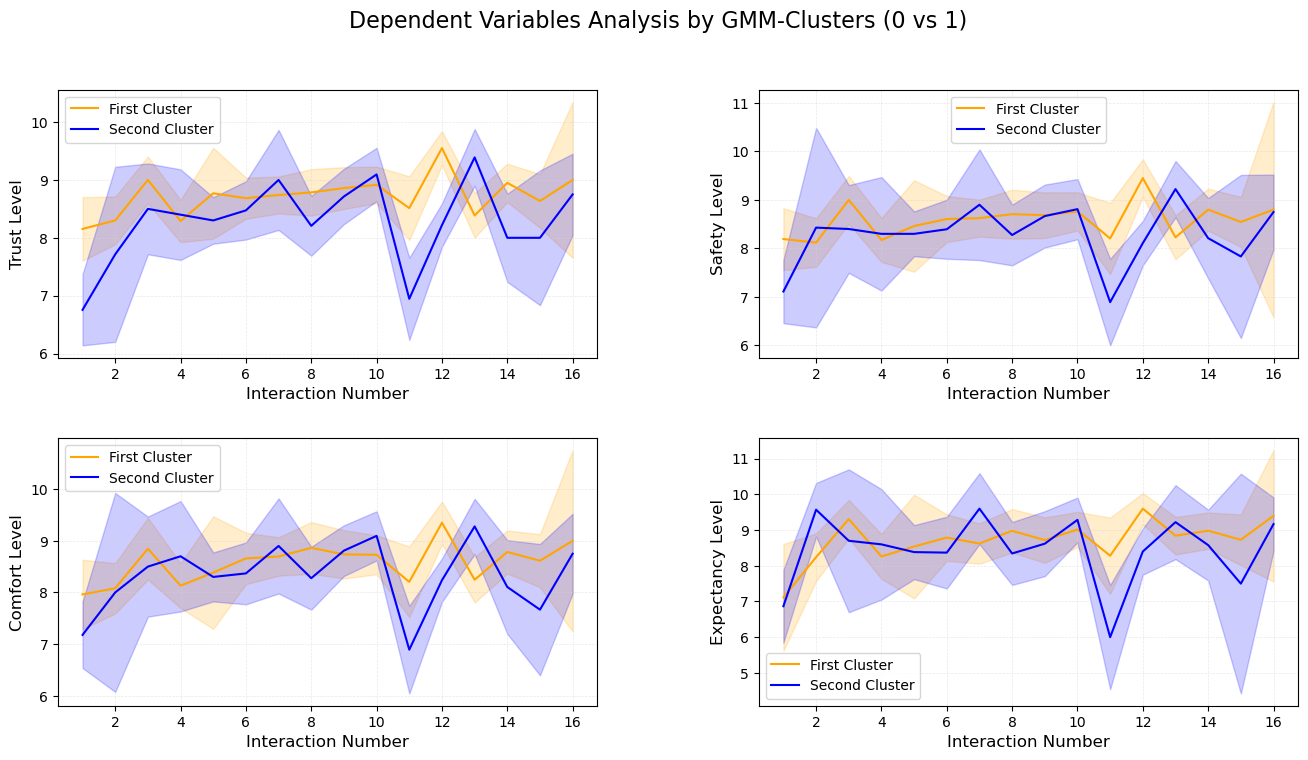

In [140]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex=False)

# Trust Plot
axs[0, 0].plot(cross_first_data_first_trust['Interaction No'], cross_first_data_first_trust['Trust_mean'], label='First Cluster', color='orange')
axs[0, 0].fill_between(cross_first_data_first_trust['Interaction No'], cross_first_data_first_trust['Trust_ci_lower'], cross_first_data_first_trust['Trust_ci_upper'], color='orange', alpha=0.20)
axs[0, 0].plot(cross_first_data_second_trust['Interaction No'], cross_first_data_second_trust['Trust_mean'], label='Second Cluster', color='blue')
axs[0, 0].fill_between(cross_first_data_second_trust['Interaction No'], cross_first_data_second_trust['Trust_ci_lower'], cross_first_data_second_trust['Trust_ci_upper'], color='blue', alpha=0.20)
axs[0, 0].set_ylabel('Trust Level', fontsize=12)
axs[0, 0].set_xlabel('Interaction Number', fontsize=12)
axs[0, 0].tick_params(axis='both', which='major', labelsize=10)
axs[0, 0].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0, 0].legend(fontsize=10)

# Safe Plot
axs[0, 1].plot(cross_first_data_first_safe['Interaction No'], cross_first_data_first_safe['Safe_mean'], label='First Cluster', color='orange')
axs[0, 1].fill_between(cross_first_data_first_safe['Interaction No'], cross_first_data_first_safe['Safe_ci_lower'], cross_first_data_first_safe['Safe_ci_upper'], color='orange', alpha=0.20)
axs[0, 1].plot(cross_first_data_second_safe['Interaction No'], cross_first_data_second_safe['Safe_mean'], label='Second Cluster', color='blue')
axs[0, 1].fill_between(cross_first_data_second_safe['Interaction No'], cross_first_data_second_safe['Safe_ci_lower'], cross_first_data_second_safe['Safe_ci_upper'], color='blue', alpha=0.20)
axs[0, 1].set_ylabel('Safety Level', fontsize=12)
axs[0, 1].set_xlabel('Interaction Number', fontsize=12)
axs[0, 1].tick_params(axis='both', which='major', labelsize=10)
axs[0, 1].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0, 1].legend(fontsize=10)

# Comfort Plot
axs[1, 0].plot(cross_first_data_first_comfort['Interaction No'], cross_first_data_first_comfort['Comfort_mean'], label='First Cluster', color='orange')
axs[1, 0].fill_between(cross_first_data_first_comfort['Interaction No'], cross_first_data_first_comfort['Comfort_ci_lower'], cross_first_data_first_comfort['Comfort_ci_upper'], color='orange', alpha=0.20)
axs[1, 0].plot(cross_first_data_second_comfort['Interaction No'], cross_first_data_second_comfort['Comfort_mean'], label='Second Cluster', color='blue')
axs[1, 0].fill_between(cross_first_data_second_comfort['Interaction No'], cross_first_data_second_comfort['Comfort_ci_lower'], cross_first_data_second_comfort['Comfort_ci_upper'], color='blue', alpha=0.20)
axs[1, 0].set_ylabel('Comfort Level', fontsize=12)
axs[1, 0].set_xlabel('Interaction Number', fontsize=12)
axs[1, 0].tick_params(axis='both', which='major', labelsize=10)
axs[1, 0].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)
axs[1, 0].legend(fontsize=10)

# Expectancy Plot
axs[1, 1].plot(cross_first_data_first_expect['Interaction No'], cross_first_data_first_expect['Expect_mean'], label='First Cluster', color='orange')
axs[1, 1].fill_between(cross_first_data_first_expect['Interaction No'], cross_first_data_first_expect['Expect_ci_lower'], cross_first_data_first_expect['Expect_ci_upper'], color='orange', alpha=0.20)
axs[1, 1].plot(cross_first_data_second_expect['Interaction No'], cross_first_data_second_expect['Expect_mean'], label='Second Cluster', color='blue')
axs[1, 1].fill_between(cross_first_data_second_expect['Interaction No'], cross_first_data_second_expect['Expect_ci_lower'], cross_first_data_second_expect['Expect_ci_upper'], color='blue', alpha=0.20)
axs[1, 1].set_ylabel('Expectancy Level', fontsize=12)
axs[1, 1].set_xlabel('Interaction Number', fontsize=12)
axs[1, 1].tick_params(axis='both', which='major', labelsize=10)
axs[1, 1].grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)
axs[1, 1].legend(fontsize=10)

# Adjust layout
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.suptitle('Dependent Variables Analysis by GMM-Clusters (0 vs 1)', fontsize=16)

filename = f'Dependent Variables Analysis by GMM-Clusters (0 vs 1).png'
full_path = os.path.join(box_path + save_dir, filename)  
# plt.savefig(full_path, dpi=300)

plt.show()

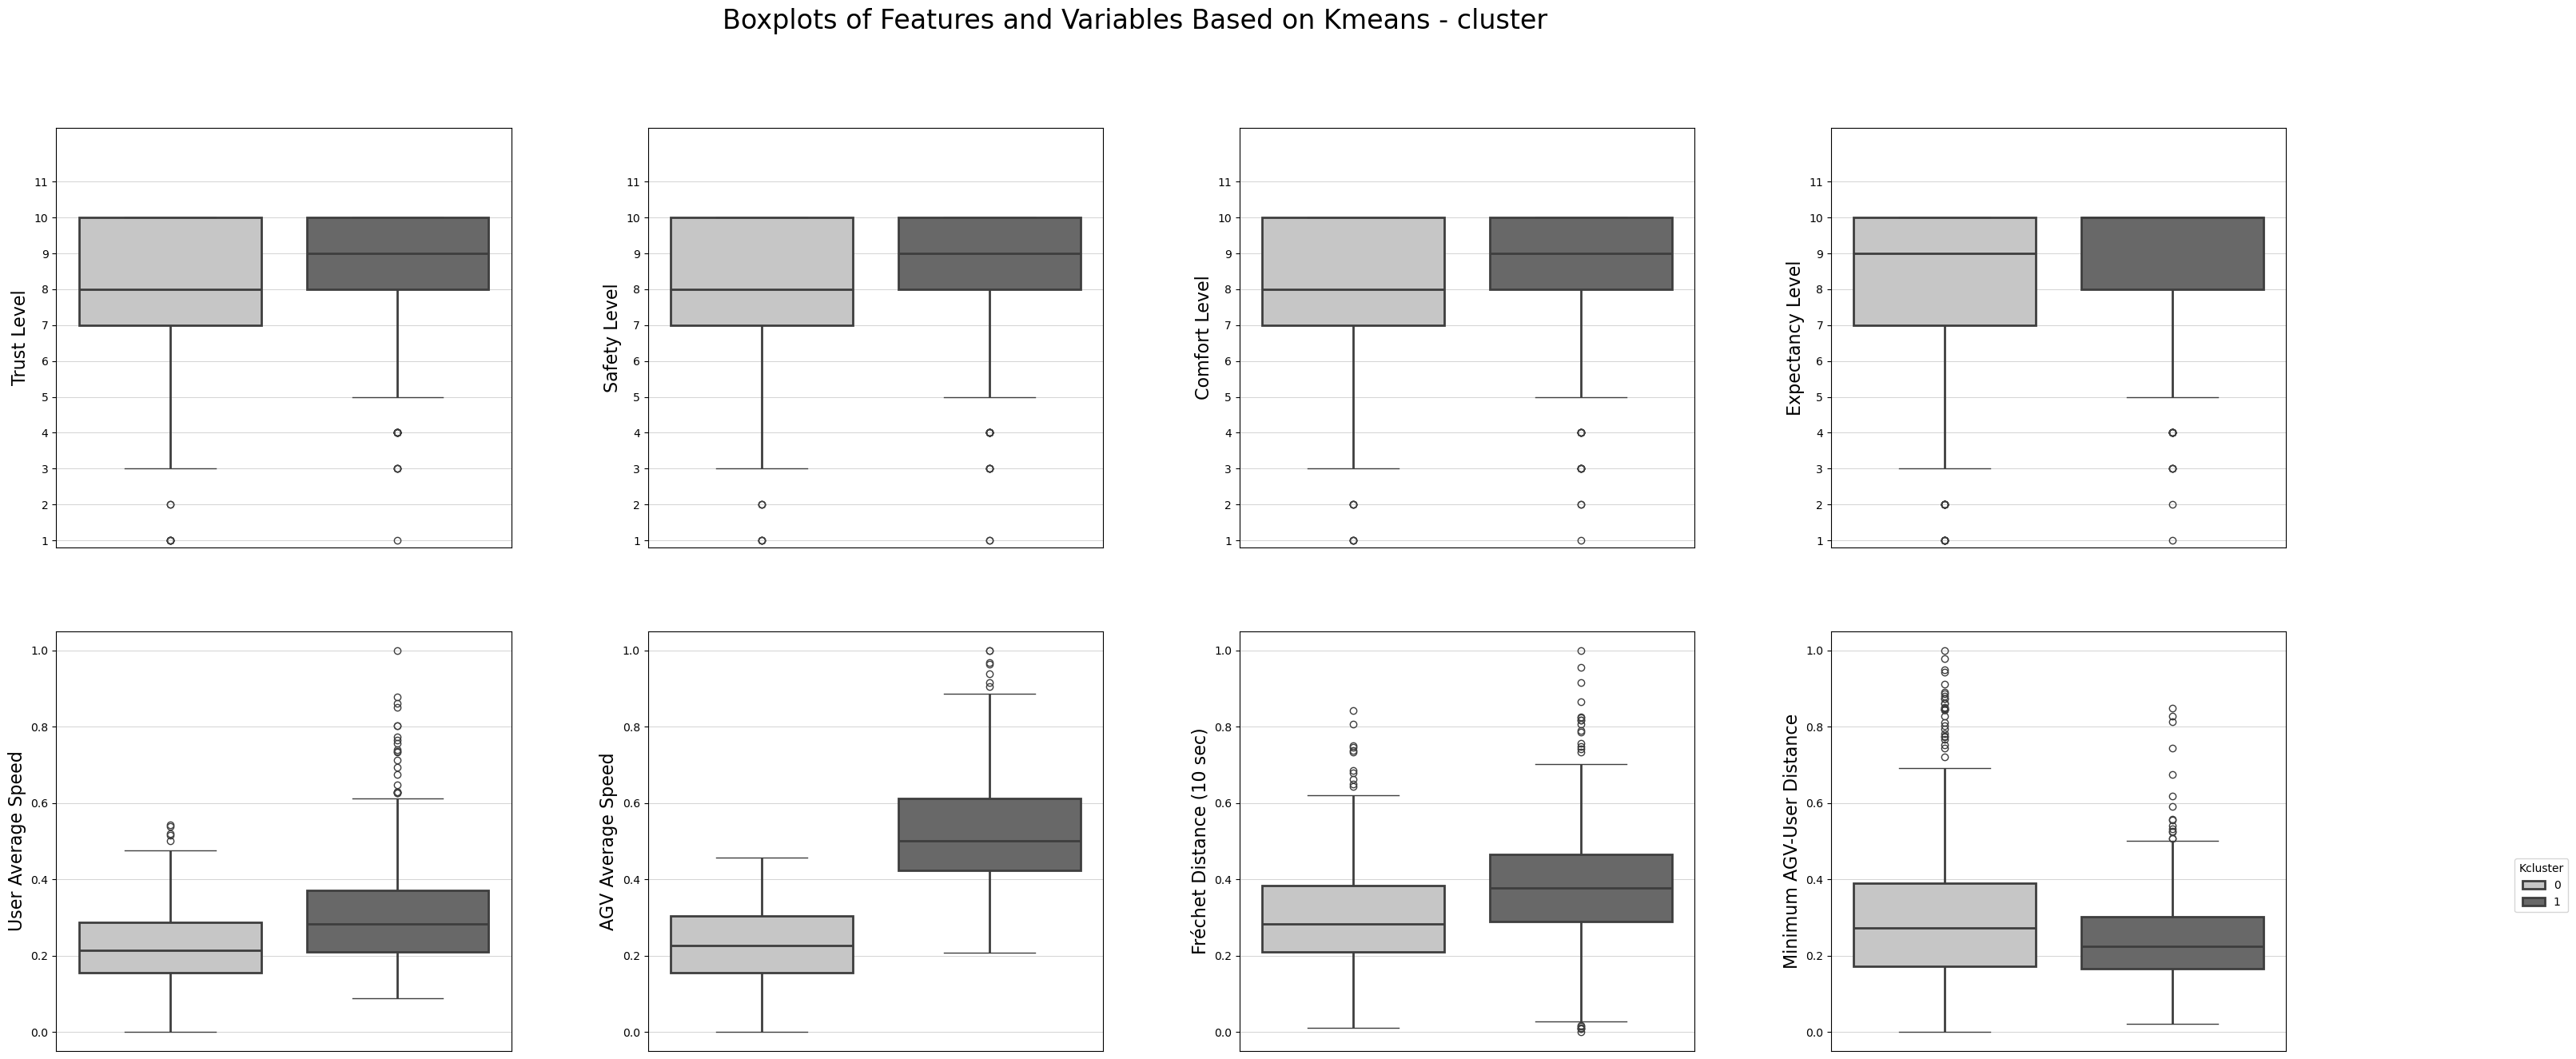

In [172]:
palette = sns.color_palette('Greys', n_colors = cross_first_data['Kcluster'].nunique())

fig, axes = plt.subplots(2, 4, figsize = (36, 15))

# Specify the order of the x values
custom_order = ['0', '1']

sns.boxplot(ax = axes[0, 0],
    x = 'Kcluster', y = 'Trust', 
    data = cross_first_data, hue = 'Kcluster', palette=palette, legend = True, dodge = False, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Trust Level", fontsize=16)
axes[0, 0].set_ylim(0.8, 12.5)
axes[0, 0].set_yticks(range(1, 12))
axes[0, 0].set_xticks([])
axes[0, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[0, 1],
    x = 'Kcluster', y = 'Safe', 
    data = cross_first_data, hue = 'Kcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Safety Level", fontsize=16)
axes[0, 1].set_ylim(0.8, 12.5)
axes[0, 1].set_yticks(range(1, 12))
axes[0, 1].set_xticks([])
axes[0, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[0, 2],
    x = 'Kcluster', y = 'Comfort', 
    data = cross_first_data, hue = 'Kcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("Comfort Level", fontsize=16)
axes[0, 2].set_ylim(0.8, 12.5)
axes[0, 2].set_yticks(range(1, 12))
axes[0, 2].set_xticks([])
axes[0, 2].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[0, 3],
    x = 'Kcluster', y = 'Expect', 
    data = cross_first_data, hue = 'Kcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 3].set_xlabel("")
axes[0, 3].set_ylabel("Expectancy Level", fontsize=16)
axes[0, 3].set_ylim(0.8, 12.5)
axes[0, 3].set_yticks(range(1, 12))
axes[0, 3].set_xticks([])
axes[0, 3].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 0],
    x = 'Kcluster', y = 'User_Relative_Speed_y', 
    data = cross_first_data, hue = 'Kcluster', palette=palette, legend = True, dodge = False, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("User Average Speed", fontsize=16)
axes[1, 0].set_xticks([])
axes[1, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 1],
    x = 'Kcluster', y = 'AGV_Relative_Speed_y', 
    data = cross_first_data, hue = 'Kcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("AGV Average Speed", fontsize=16)
axes[1, 1].set_xticks([])
axes[1, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 2],
    x = 'Kcluster', y = 'Frechet_Distance_10_y', 
    data = cross_first_data, hue = 'Kcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Fréchet Distance (10 sec)", fontsize=16)
axes[1, 2].set_xticks([])
axes[1, 2].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 3],
    x = 'Kcluster', y = 'AGV_User_Distance_Min_y', 
    data = cross_first_data, hue = 'Kcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 3].set_xlabel("")
axes[1, 3].set_ylabel("Minimum AGV-User Distance", fontsize=16)
axes[1, 3].set_xticks([])
axes[1, 3].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

# Creating a single legend for the whole plot
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title = 'Kcluster', bbox_to_anchor=(1, 0.275))
fig.suptitle("Boxplots of Features and Variables Based on Kmeans - cluster", fontsize=24)

# Removing the legends, because we wanted the first one to only save it for the whole plot
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.subplots_adjust(wspace=0.3, hspace=0.2)

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'boxplots_of_features_variables_based_on_km_clusters.png'
full_path = os.path.join(box_path + save_dir, filename) 
plt.savefig(full_path, bbox_inches = 'tight', pad_inches=0.1, dpi=300)

plt.show()

In [179]:
anova_table = pg.anova(dv = 'User_Relative_Speed_y', between = ['Kcluster'], data = cross_first_data, detailed=True)

formatted_anova_table = anova_table.applymap(lambda x: f'{x:.3f}' if isinstance(x, (int, float)) else x)

formatted_anova_table

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\3942020099.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f'{x:.3f}' if isinstance(x, (int, float)) else x)


,Source,SS,DF,MS,F,p-unc,np2
0,Kcluster,1.721,1.000,1.721,116.004,0.000,0.098
1,Within,15.811,1066.000,0.015,nan,nan,nan


In [148]:
# Extracting groups
group1 = cross_first_data['User_Relative_Speed_y'][cross_first_data['Kcluster'] == 0]
group2 = cross_first_data['User_Relative_Speed_y'][cross_first_data['Kcluster'] == 1]

# Perform the independent t-test
t_stat, p_value = ttest_ind(group1, group2, equal_var=False)  # Use equal_var=False if variances are unequal
print(f"T-statistic: {t_stat}, P-value: {p_value}")

# Interpretation
alpha = 0.05  # Significance level
if p_value < alpha:
    print("The difference between the groups is statistically significant.")
else:
    print("The difference between the groups is not statistically significant.")

T-statistic: -10.807409825769778, P-value: 9.271252731681461e-26
The difference between the groups is statistically significant.


In [182]:
# Fit the model
model = smf.ols('AGV_Relative_Speed_y ~ Kcluster', data = cross_first_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p<0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

                df sum_sq mean_sq         F   PR(>F)
Kcluster         1   22.2    22.2  1.53e+03  0.000**
Residual  1.07e+03   15.4  0.0145       nan      nan


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\87683980.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


In [196]:
# Fit the model
model = smf.ols('AGV_Relative_Speed_y ~ GMMcluster', data = cross_first_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p<0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

                  df sum_sq mean_sq    F   PR(>F)
GMMcluster         1   17.5    17.5  932  0.000**
Residual    1.07e+03     20  0.0188  nan      nan


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\2437585763.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


In [184]:
# Fit the model
model = smf.ols('User_Relative_Speed_y ~ Kcluster', data = cross_first_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p<0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

                df sum_sq mean_sq    F   PR(>F)
Kcluster         1   1.72    1.72  116  0.000**
Residual  1.07e+03   15.8  0.0148  nan      nan


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\3030437074.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


In [198]:
# Fit the model
model = smf.ols('User_Relative_Speed_y ~ GMMcluster', data = cross_first_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p<0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

                  df sum_sq mean_sq     F   PR(>F)
GMMcluster         1  0.707   0.707  44.8  0.000**
Residual    1.07e+03   16.8  0.0158   nan      nan


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\2523210746.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


In [188]:
# Fit the model
model = smf.ols('Frechet_Distance_10_y ~ Kcluster', data = cross_first_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p < 0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

                df sum_sq mean_sq     F   PR(>F)
Kcluster         1   1.93    1.93  89.7  0.000**
Residual  1.07e+03     23  0.0216   nan      nan


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\358740693.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


In [200]:
# Fit the model
model = smf.ols('Frechet_Distance_10_y ~ GMMcluster', data = cross_first_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p < 0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

                  df sum_sq mean_sq     F   PR(>F)
GMMcluster         1   1.87    1.87  86.3  0.000**
Residual    1.07e+03   23.1  0.0216   nan      nan


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\473466492.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


In [190]:
# Fit the model
model = smf.ols('AGV_User_Distance_Min_y ~ Kcluster', data = cross_first_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p < 0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

                df sum_sq mean_sq     F   PR(>F)
Kcluster         1   1.13    1.13  45.1  0.000**
Residual  1.07e+03   26.7   0.025   nan      nan


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\1426847600.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


In [202]:
# Fit the model
model = smf.ols('AGV_User_Distance_Min_y ~ GMMcluster', data = cross_first_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p < 0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

                  df sum_sq mean_sq    F   PR(>F)
GMMcluster         1   2.88    2.88  123  0.000**
Residual    1.07e+03   24.9  0.0234  nan      nan


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\2719072663.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


In [192]:
# Fit the model
model = smf.ols('Duration ~ Kcluster', data = cross_first_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p < 0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

                df    sum_sq   mean_sq    F   PR(>F)
Kcluster         1  2.06e+05  2.06e+05  950  0.000**
Residual  1.07e+03  2.32e+05       217  nan      nan


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\4259705357.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


In [204]:
# Fit the model
model = smf.ols('Duration ~ GMMcluster', data = cross_first_data).fit()

#Perform ANOVA
anova_table = sm.stats.anova_lm(model, type=2)

def format_p_value(p):
    return f"{p:.3f}**" if p < 0.05 else f"{p:.3f}"

# Apply the function to the 'PR(>F)' column
anova_table['PR(>F)'] = anova_table['PR(>F)'].apply(format_p_value)

formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)

print(formatted_anova_table)

                  df    sum_sq   mean_sq    F   PR(>F)
GMMcluster         1  1.94e+05  1.94e+05  849  0.000**
Residual    1.07e+03  2.44e+05       229  nan      nan


C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\3042680339.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_anova_table = anova_table.applymap(lambda x: f"{x:.3g}" if isinstance(x, (int, float)) else x)


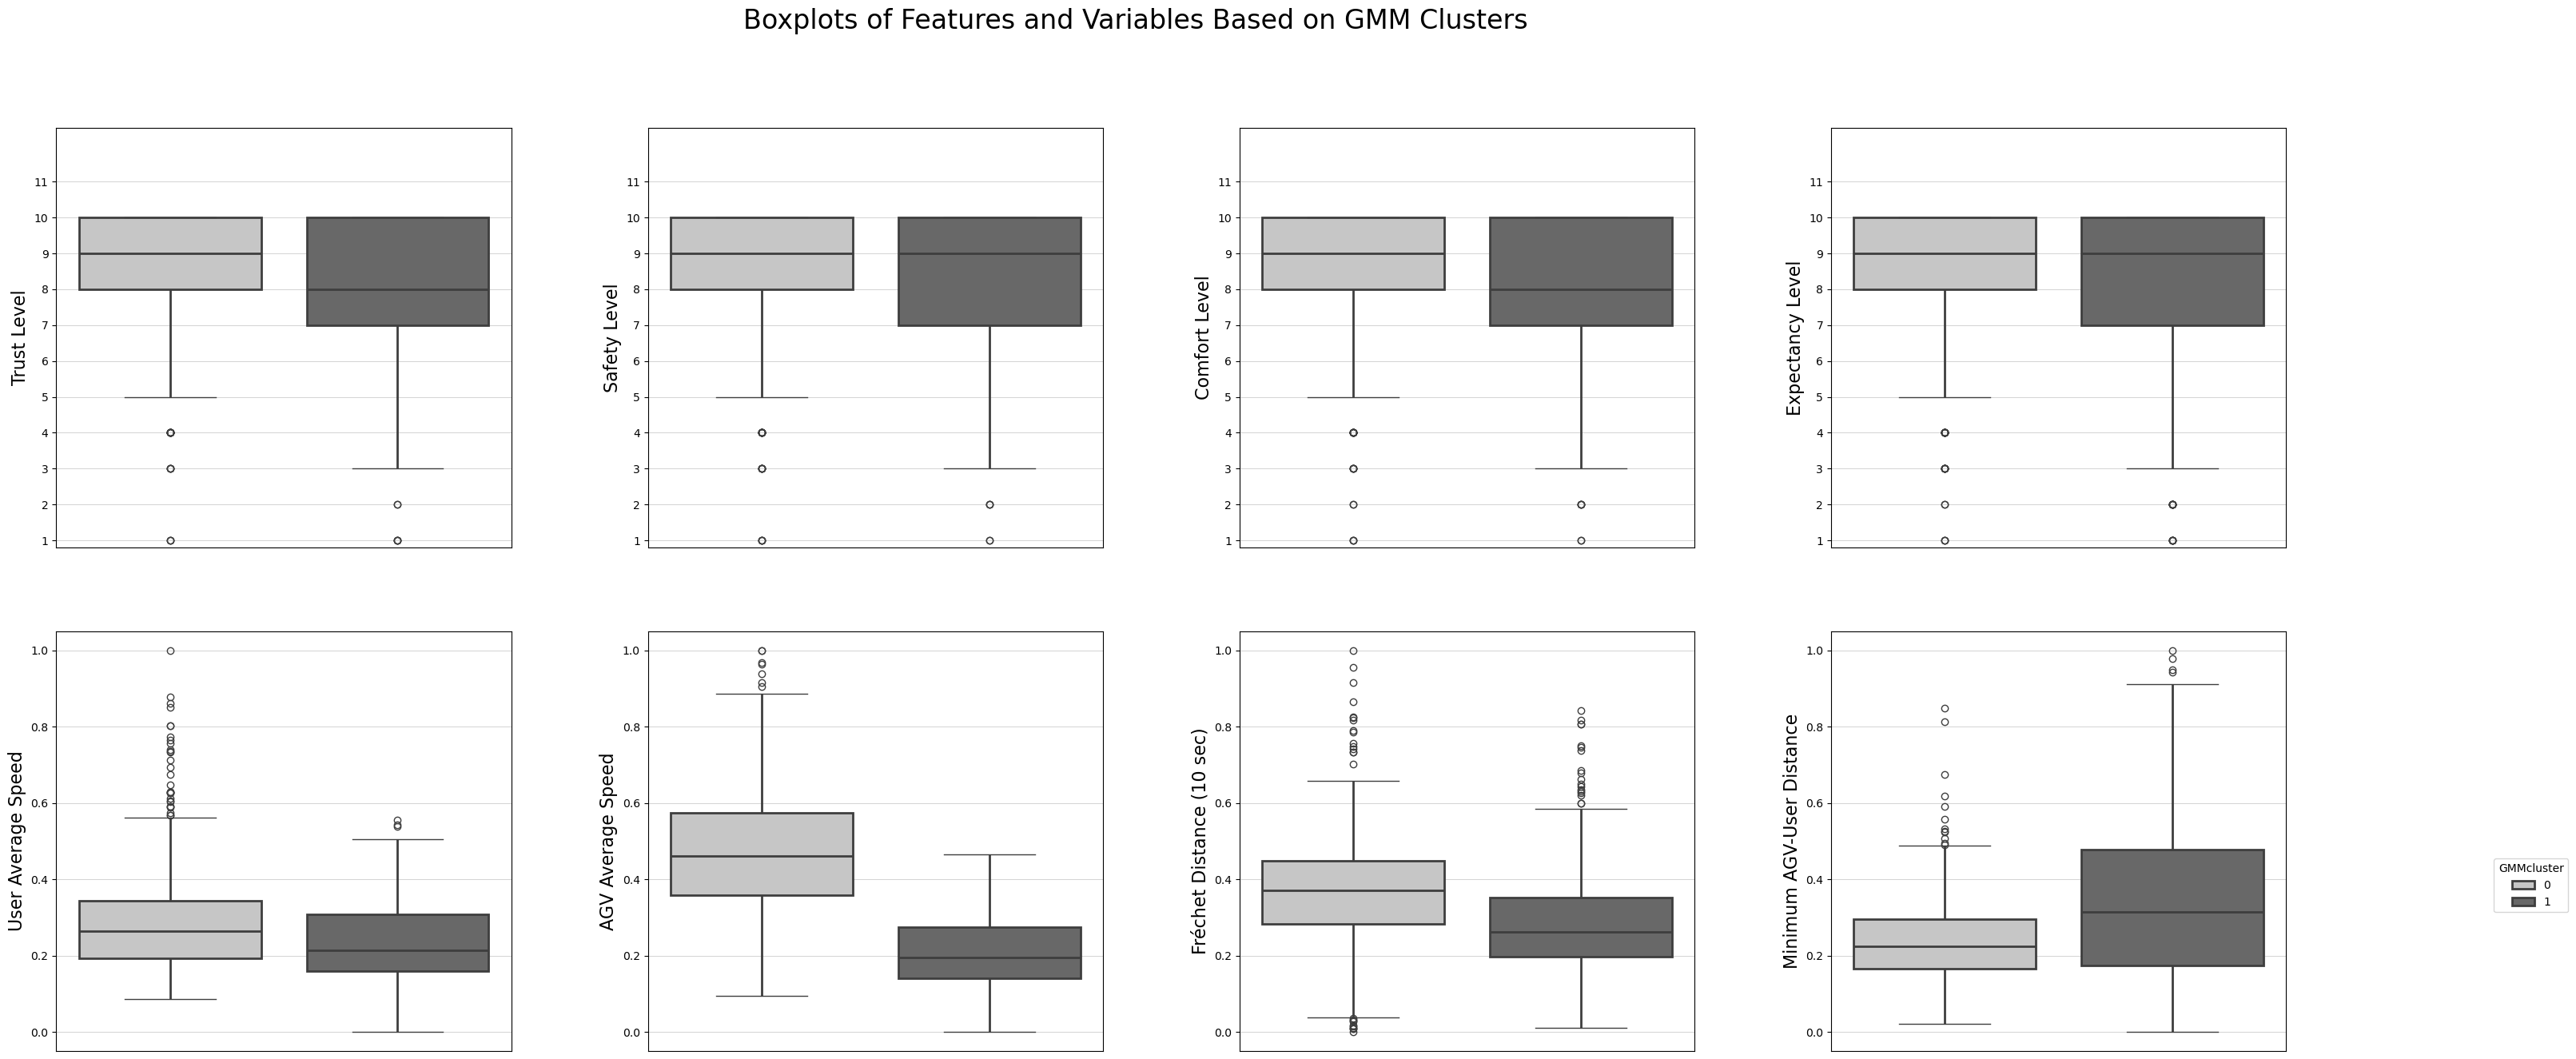

In [174]:
palette = sns.color_palette('Greys', n_colors = cross_first_data['GMMcluster'].nunique())

fig, axes = plt.subplots(2, 4, figsize = (36, 15))

# Specify the order of the x values
custom_order = ['0', '1']

sns.boxplot(ax = axes[0, 0],
    x = 'GMMcluster', y = 'Trust', 
    data = cross_first_data, hue = 'GMMcluster', palette=palette, legend = True, dodge = False, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Trust Level", fontsize=16)
axes[0, 0].set_ylim(0.8, 12.5)
axes[0, 0].set_yticks(range(1, 12))
axes[0, 0].set_xticks([])
axes[0, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[0, 1],
    x = 'GMMcluster', y = 'Safe', 
    data = cross_first_data, hue = 'GMMcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Safety Level", fontsize=16)
axes[0, 1].set_ylim(0.8, 12.5)
axes[0, 1].set_yticks(range(1, 12))
axes[0, 1].set_xticks([])
axes[0, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[0, 2],
    x = 'GMMcluster', y = 'Comfort', 
    data = cross_first_data, hue = 'GMMcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("Comfort Level", fontsize=16)
axes[0, 2].set_ylim(0.8, 12.5)
axes[0, 2].set_yticks(range(1, 12))
axes[0, 2].set_xticks([])
axes[0, 2].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[0, 3],
    x = 'GMMcluster', y = 'Expect', 
    data = cross_first_data, hue = 'GMMcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[0, 3].set_xlabel("")
axes[0, 3].set_ylabel("Expectancy Level", fontsize=16)
axes[0, 3].set_ylim(0.8, 12.5)
axes[0, 3].set_yticks(range(1, 12))
axes[0, 3].set_xticks([])
axes[0, 3].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 0],
    x = 'GMMcluster', y = 'User_Relative_Speed_y', 
    data = cross_first_data, hue = 'GMMcluster', palette=palette, legend = True, dodge = False, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("User Average Speed", fontsize=16)
axes[1, 0].set_xticks([])
axes[1, 0].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 1],
    x = 'GMMcluster', y = 'AGV_Relative_Speed_y', 
    data = cross_first_data, hue = 'GMMcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("AGV Average Speed", fontsize=16)
axes[1, 1].set_xticks([])
axes[1, 1].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 2],
    x = 'GMMcluster', y = 'Frechet_Distance_10_y', 
    data = cross_first_data, hue = 'GMMcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Fréchet Distance (10 sec)", fontsize=16)
axes[1, 2].set_xticks([])
axes[1, 2].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

sns.boxplot(ax = axes[1, 3],
    x = 'GMMcluster', y = 'AGV_User_Distance_Min_y', 
    data = cross_first_data, hue = 'GMMcluster', palette=palette, order = custom_order, linewidth = 2,
    whiskerprops = {'linewidth': 2.0},
    capprops = {'linewidth':1.0}
)
axes[1, 3].set_xlabel("")
axes[1, 3].set_ylabel("Minimum AGV-User Distance", fontsize=16)
axes[1, 3].set_xticks([])
axes[1, 3].grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.7)

# Creating a single legend for the whole plot
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title = 'GMMcluster', bbox_to_anchor=(1, 0.275))
fig.suptitle("Boxplots of Features and Variables Based on GMM Clusters", fontsize=24)

# Removing the legends, because we wanted the first one to only save it for the whole plot
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.subplots_adjust(wspace=0.3, hspace=0.2)

# generate a timestamp for the uniqueness 
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define the filename with timestamp
filename = f'boxplots_of_features_variables_based_on_gm_clusters.png'
full_path = os.path.join(box_path + save_dir, filename) 
plt.savefig(full_path, bbox_inches = 'tight', pad_inches=0.1, dpi=300)

plt.show()

### Clustering with PCA

In [219]:
def random_centroids(data, k):
    centroids = []
    for i in range(k):
        centroid = data.apply(lambda x: float(x.sample()))
        centroids.append(centroid)
    return pd.concat(centroids, axis = 1)

In [221]:
def get_labels(data, centroids):
    distances = centroids.apply(lambda x: np.sqrt(((data - x) ** 2).sum(axis = 1)))
    return distances.idxmin(axis = 1)

In [223]:
def new_centroids(data, labels, k):
    return clustering_data.groupby(labels).apply(lambda x: np.exp(np.log(x).mean())).T

In [225]:
def plot_clusters(data, labels, centroids, iteration):
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)
    centroids_2d = pca.transform(centroids.T)
    clear_output(wait=True)
    plt.title(f'Iteration {iteration}')
    plt.scatter(x=data_2d[:,0], y=data_2d[:,1], c=labels)
    plt.scatter(x=centroids_2d[:,0], y=centroids_2d[:,1])
    plt.grid(True)
    filename = f"Clustering_with_K_being_Five.png"
    full_path = os.path.join(box_path + save_dir, filename)
    # plt.savefig(full_path, dpi=600)
    plt.show()

max_iterations = 100
centroid_count = 2

centroids = random_centroids(clustering_data, centroid_count)
old_centroids = pd.DataFrame()
iteration = 1

while iteration < max_iterations and not centroids.equals(old_centroids):
    old_centroids = centroids
    
    labels = get_labels(clustering_data, centroids)
    centroids = new_centroids(clustering_data, labels, centroid_count)
    plot_clusters(clustering_data, labels, centroids, iteration)
    iteration += 1

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_81608\3053968953.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  centroid = data.apply(lambda x: float(x.sample()))


ValueError: could not convert string to float: 'Low'

In [ ]:
with pd.option_context('display.float_format', '{:.2g}'.format):
    print(centroids)

In [ ]:
kmeans = KMeans(2)
kmeans.fit(clustering_data)

In [ ]:
with pd.option_context('display.float_format', '{:.2g}'.format):
    print(pd.DataFrame(kmeans.cluster_centers_, columns=features).T)